In [ ]:
# ─── Environment Setup (do not edit) ────────────────────────────────────────
import os, sys
from pathlib import Path


def _detect_platform():
    try:
        import google.colab  # noqa: F401

        return "colab", False
    except ImportError:
        pass
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    if Path("/workspace").exists():
        return "vastai", True
    if sys.platform == "win32":
        return "windows", False
    if sys.platform == "darwin":
        return "mac", False
    return None, True


PLATFORM, _uncertain = _detect_platform()

if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
else:
    PROJECT_ROOT = _nb_path.parents[1]

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

_env_map = {
    "colab": PROJECT_ROOT / ".env.colab",
    "vastai": PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac": PROJECT_ROOT / ".env.mac",
}
_env_file = _env_map.get(PLATFORM, PROJECT_ROOT / ".env")

from dotenv import load_dotenv

if not _env_file.exists():
    _fallback = PROJECT_ROOT / ".env"
    _env_file = _fallback if _fallback.exists() else _env_file

load_dotenv(_env_file, override=True)

from utils.env_utils import get_data_root

DATA_ROOT = get_data_root()

print(f"✅ Platform : {PLATFORM or 'unknown'}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print(f"{'✅' if DATA_ROOT.exists() else '❌'} Path exists: {DATA_ROOT.exists()}")
# ─────────────────────────────────────────────────────────────────────────────

✅ Platform : mac
✅ DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
✅ Path exists: True


# Phân tích Dữ liệu Hình ảnh & Chú thích (Image–Caption EDA)

Notebook này phân tích **toàn bộ dữ liệu hình ảnh và chú thích (caption)** crawl từ 6 báo điện tử tiếng Việt,  
phục vụ báo cáo thực nghiệm luận văn.

**Nội dung phân tích:**

1. Tổng quan dữ liệu hình ảnh
2. Phân bố số lượng ảnh theo split & domain
3. Phân bố số ảnh trên mỗi bài viết
4. Phân tích caption (độ dài ký tự & từ)
5. Tỉ lệ ảnh có caption vs không có caption (per domain)
6. Mức độ tái sử dụng ảnh giữa các bài
7. Kích thước file ảnh
8. Bảng tổng hợp toàn bộ chỉ số


In [ ]:
import json
import warnings
import os
import struct
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

SPLIT_COLORS = {"train": "#3498db", "dev": "#9b59b6", "test": "#e67e22"}

DOMAIN_COLORS = {
    "baochinhphu.vn": "#1f77b4",
    "baotintuc.vn": "#ff7f0e",
    "dantri.com.vn": "#2ca02c",
    "nld.com.vn": "#d62728",
    "plo.vn": "#9467bd",
    "thanhnien.vn": "#8c564b",
    "tienphong.vn": "#e377c2",
    "tuoitre.vn": "#7f7f7f",
    "vnexpress.net": "#bcbd22",
}

DOMAIN_SHORT = {
    "baochinhphu.vn": "BaoChinhPhu",
    "baotintuc.vn": "BaoTinTuc",
    "dantri.com.vn": "DanTri",
    "nld.com.vn": "NLD",
    "plo.vn": "PLO",
    "thanhnien.vn": "ThanhNien",
    "tienphong.vn": "TienPhong",
    "tuoitre.vn": "TuoiTre",
    "vnexpress.net": "VNExpress",
}

OUTPUT_DIR = Path(".")
print("✅ Imports ready.")

✅ Imports ready.


## 1. Tải và chuẩn bị dữ liệu


In [ ]:
JSON_DIR = DATA_ROOT / "data" / "json"
IMG_DIR = DATA_ROOT / "data" / "jpg"

records = []  # article-level records
img_records = []  # image-level records

for split in ["train", "dev", "test"]:
    path = JSON_DIR / f"news_data_vifactcheck_{split}_labeled.json"
    with open(path) as f:
        crawled = json.load(f)
    for rec in crawled:
        feat = rec["features"]
        meta = rec["metadata"]
        imgs = rec.get("media", {}).get("images", [])
        domain = feat.get("domain", "")

        records.append(
            {
                "id": rec["id"],
                "split": split,
                "domain": domain,
                "has_images": feat.get("has_images", False),
                "image_count": len(imgs),
                "crawl_success": meta.get("success", False),
            }
        )

        for img in imgs:
            cap = img.get("caption", "").strip()
            alt = img.get("alt_text", "").strip()
            img_path = DATA_ROOT / "data" / img["path"]

            # Caption word count (simple split)
            cap_words = len(cap.split()) if cap else 0
            cap_chars = len(cap) if cap else 0

            img_records.append(
                {
                    "article_id": rec["id"],
                    "split": split,
                    "domain": domain,
                    "path": img["path"],
                    "url": img.get("url", ""),
                    "caption": cap,
                    "alt_text": alt,
                    "has_caption": bool(cap),
                    "has_alttext": bool(alt),
                    "cap_chars": cap_chars,
                    "cap_words": cap_words,
                    "file_exists": img_path.exists(),
                    "file_size_kb": (
                        img_path.stat().st_size / 1024 if img_path.exists() else 0
                    ),
                }
            )

df_art = pd.DataFrame(records)
df_img = pd.DataFrame(img_records)

# Unique image paths
unique_paths = df_img["path"].unique()
path_reuse = df_img["path"].value_counts()

print(
    f"✅ Articles : {len(df_art):,}  (train={len(df_art[df_art.split=='train']):,} | dev={len(df_art[df_art.split=='dev']):,} | test={len(df_art[df_art.split=='test']):,})"
)
print(
    f"✅ Image refs: {len(df_img):,}  |  Unique files: {len(unique_paths):,}  |  Duplicate refs: {len(df_img)-len(unique_paths):,}"
)
print(
    f"✅ Articles with images: {df_art.has_images.sum():,} / {len(df_art):,}  ({df_art.has_images.mean()*100:.1f}%)"
)
print(
    f"✅ Images with caption : {df_img.has_caption.sum():,} / {len(df_img):,}  ({df_img.has_caption.mean()*100:.1f}%)"
)
print(
    f"✅ Images with alt_text: {df_img.has_alttext.sum():,} / {len(df_img):,}  ({df_img.has_alttext.mean()*100:.1f}%)"
)

✅ Articles : 7,232  (train=5,062 | dev=723 | test=1,447)
✅ Image refs: 9,944  |  Unique files: 1,391  |  Duplicate refs: 8,553
✅ Articles with images: 4,769 / 7,232  (65.9%)
✅ Images with caption : 9,944 / 9,944  (100.0%)
✅ Images with alt_text: 0 / 9,944  (0.0%)


## 2. Bảng tổng quan theo split


In [ ]:
rows = []
for grp in ["train", "dev", "test", "ALL"]:
    sub_a = df_art if grp == "ALL" else df_art[df_art.split == grp]
    sub_i = df_img if grp == "ALL" else df_img[df_img.split == grp]
    rows.append(
        {
            "Split": grp,
            "Bài viết": f"{len(sub_a):,}",
            "Bài có ảnh (%)": f"{sub_a.has_images.mean()*100:.1f}%",
            "Tổng ref ảnh": f"{len(sub_i):,}",
            "File ảnh duy nhất": f"{sub_i['path'].nunique():,}",
            "Ảnh có caption (%)": f"{sub_i.has_caption.mean()*100:.1f}%",
            "Caption dài TB (char)": (
                f"{sub_i[sub_i.has_caption].cap_chars.mean():.0f}"
                if sub_i.has_caption.any()
                else "—"
            ),
            "Caption TB (từ)": (
                f"{sub_i[sub_i.has_caption].cap_words.mean():.1f}"
                if sub_i.has_caption.any()
                else "—"
            ),
            "TB ảnh/bài": f"{sub_a.image_count.mean():.2f}",
        }
    )

df_overview = pd.DataFrame(rows).set_index("Split")
display(
    df_overview.style.set_caption(
        "Bảng 1: Tổng quan dữ liệu hình ảnh & caption theo split"
    )
)

,Bài viết,Bài có ảnh (%),Tổng ref ảnh,File ảnh duy nhất,Ảnh có caption (%),Caption dài TB (char),Caption TB (từ),TB ảnh/bài
Split,,,,,,,,
train,"5,062",65.6%,"6,948","1,387",100.0%,93,19.8,1.37
dev,723,65.4%,896,611,100.0%,91,19.3,1.24
test,"1,447",67.2%,"2,100","1,029",100.0%,94,20.2,1.45
ALL,"7,232",65.9%,"9,944","1,391",100.0%,93,19.8,1.38


## 3. Phân bố ảnh theo split


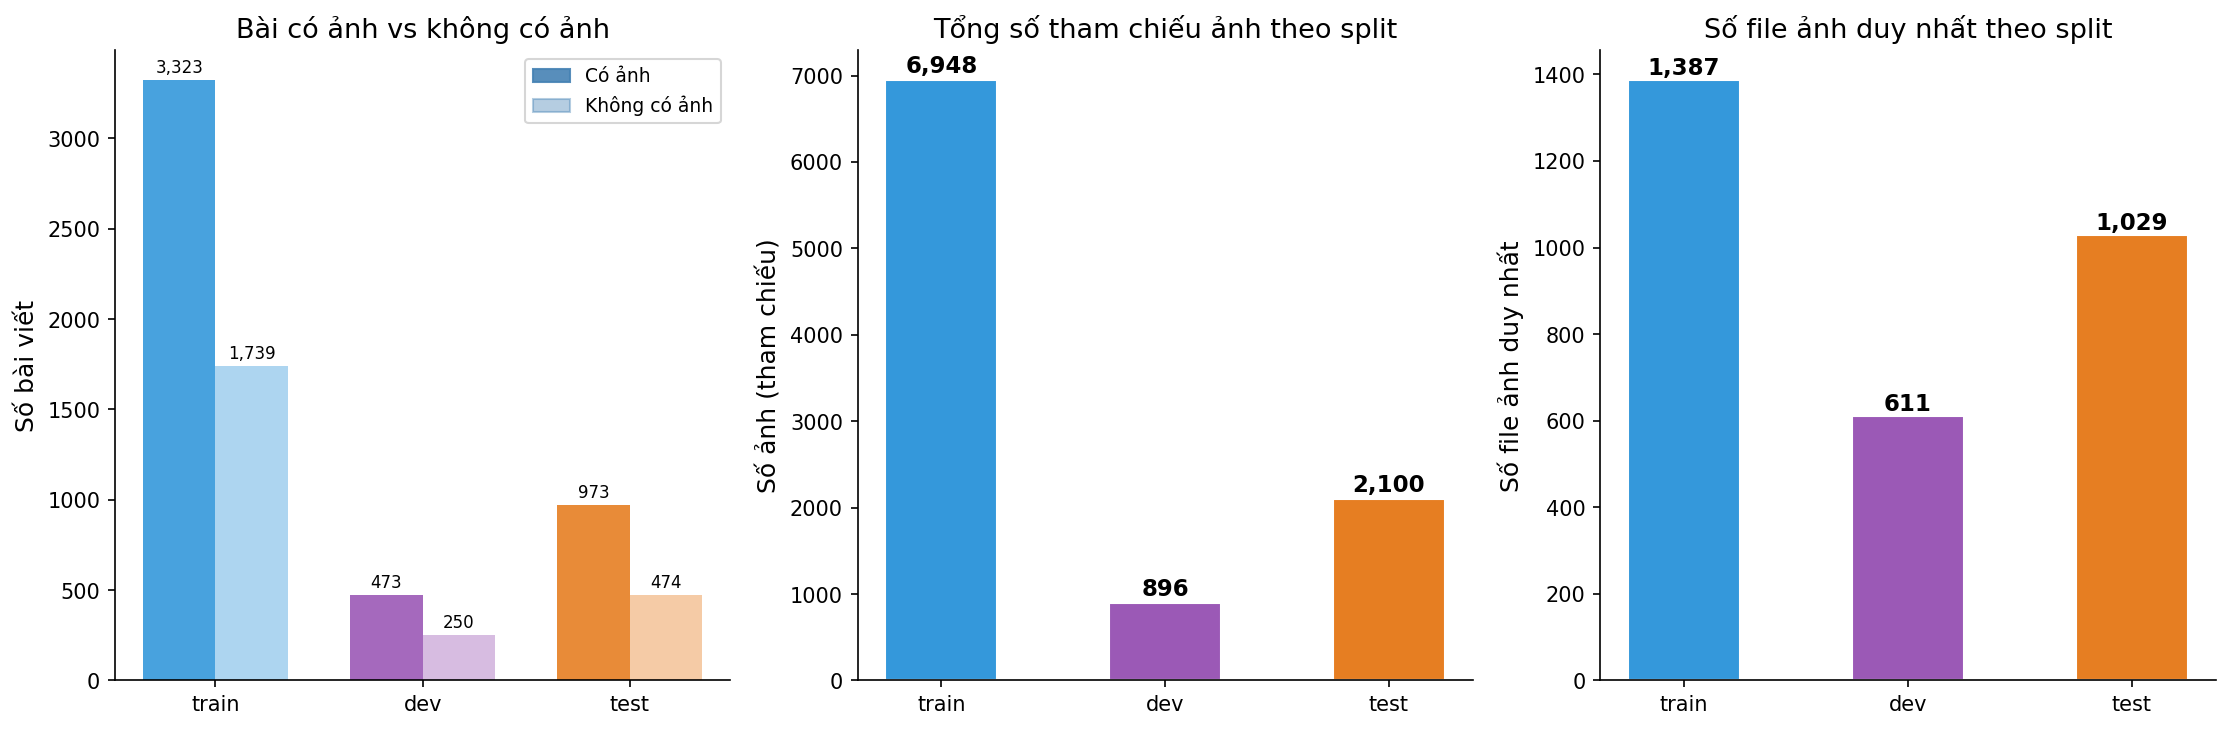

Saved: fig_d1_images_by_split.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot A: articles with/without images per split ---
split_order = ["train", "dev", "test"]
x = np.arange(len(split_order))
w = 0.35

for i, split in enumerate(split_order):
    sub = df_art[df_art.split == split]
    with_img = sub.has_images.sum()
    without_img = len(sub) - with_img
    axes[0].bar(
        i - w / 2,
        with_img,
        w,
        color=SPLIT_COLORS[split],
        alpha=0.9,
        label=split if i == 0 else "",
    )
    axes[0].bar(i + w / 2, without_img, w, color=SPLIT_COLORS[split], alpha=0.4)
    axes[0].text(
        i - w / 2, with_img + 20, f"{with_img:,}", ha="center", va="bottom", fontsize=8
    )
    axes[0].text(
        i + w / 2,
        without_img + 20,
        f"{without_img:,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(split_order)
axes[0].set_title("Bài có ảnh vs không có ảnh")
axes[0].set_ylabel("Số bài viết")
patch1 = mpatches.Patch(color="steelblue", alpha=0.9, label="Có ảnh")
patch2 = mpatches.Patch(color="steelblue", alpha=0.4, label="Không có ảnh")
axes[0].legend(handles=[patch1, patch2], fontsize=9)

# --- Plot B: total image refs per split ---
split_img_counts = df_img.groupby("split")["path"].count().reindex(split_order)
bars = axes[1].bar(
    split_order,
    split_img_counts.values,
    color=[SPLIT_COLORS[s] for s in split_order],
    edgecolor="white",
    width=0.5,
)
for bar, val in zip(bars, split_img_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
axes[1].set_title("Tổng số tham chiếu ảnh theo split")
axes[1].set_ylabel("Số ảnh (tham chiếu)")

# --- Plot C: unique image files per split ---
split_unique = df_img.groupby("split")["path"].nunique().reindex(split_order)
bars2 = axes[2].bar(
    split_order,
    split_unique.values,
    color=[SPLIT_COLORS[s] for s in split_order],
    edgecolor="white",
    width=0.5,
)
for bar, val in zip(bars2, split_unique.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
axes[2].set_title("Số file ảnh duy nhất theo split")
axes[2].set_ylabel("Số file ảnh duy nhất")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d1_images_by_split.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d1_images_by_split.png")

## 4. Phân bố ảnh theo domain


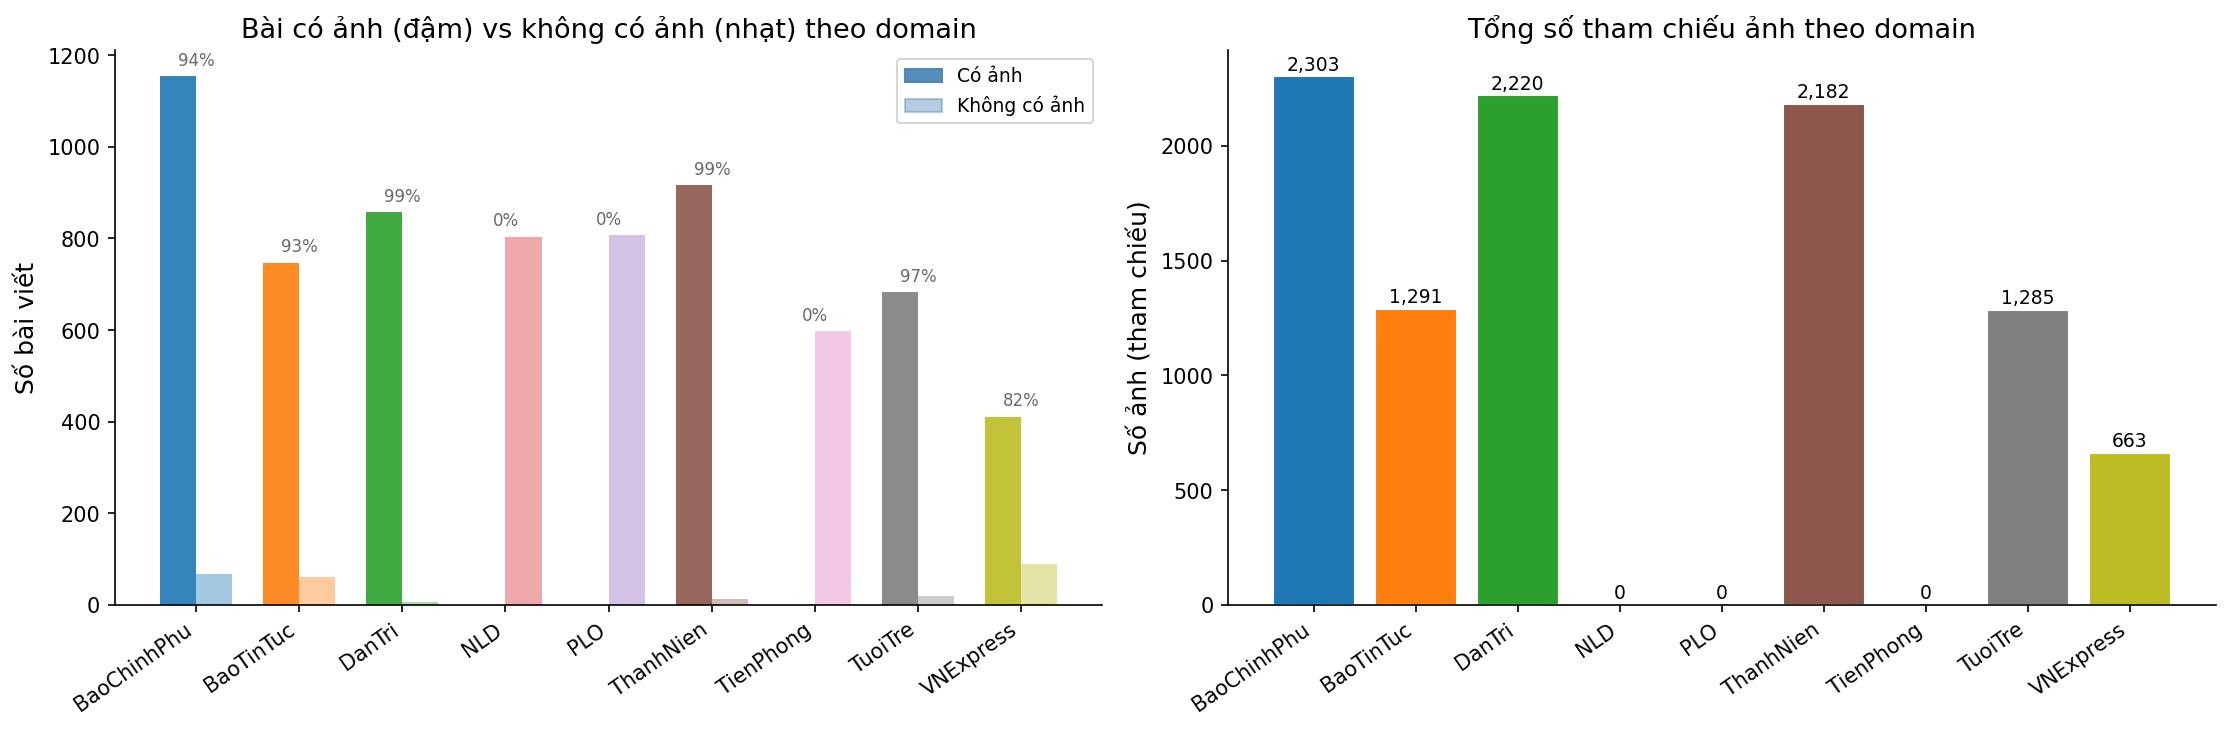

Saved: fig_d2_images_by_domain.png


In [ ]:
domains = sorted(df_art["domain"].unique())
domain_short = [DOMAIN_SHORT.get(d, d) for d in domains]
colors_d = [DOMAIN_COLORS.get(d, "#999") for d in domains]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot A: article count with/without images per domain ---
x = np.arange(len(domains))
w = 0.35
for i, d in enumerate(domains):
    sub = df_art[df_art.domain == d]
    with_img = sub.has_images.sum()
    without_img = len(sub) - with_img
    total = len(sub)
    axes[0].bar(i - w / 2, with_img, w, color=DOMAIN_COLORS.get(d, "#999"), alpha=0.9)
    axes[0].bar(
        i + w / 2, without_img, w, color=DOMAIN_COLORS.get(d, "#999"), alpha=0.4
    )
    # ratio annotation
    axes[0].text(
        i,
        max(with_img, without_img) + 15,
        f"{with_img/total*100:.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="dimgray",
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(domain_short, rotation=35, ha="right")
axes[0].set_title("Bài có ảnh (đậm) vs không có ảnh (nhạt) theo domain")
axes[0].set_ylabel("Số bài viết")
patch1 = mpatches.Patch(color="steelblue", alpha=0.9, label="Có ảnh")
patch2 = mpatches.Patch(color="steelblue", alpha=0.4, label="Không có ảnh")
axes[0].legend(handles=[patch1, patch2], fontsize=9)

# --- Plot B: total image refs per domain ---
domain_img_counts = (
    df_img.groupby("domain")["path"].count().reindex(domains).fillna(0).astype(int)
)
bars = axes[1].bar(
    domain_short, domain_img_counts.values, color=colors_d, edgecolor="white"
)
for bar, val in zip(bars, domain_img_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[1].set_xticklabels(domain_short, rotation=35, ha="right")
axes[1].set_title("Tổng số tham chiếu ảnh theo domain")
axes[1].set_ylabel("Số ảnh (tham chiếu)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d2_images_by_domain.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d2_images_by_domain.png")

## 5. Phân bố số ảnh trên mỗi bài viết


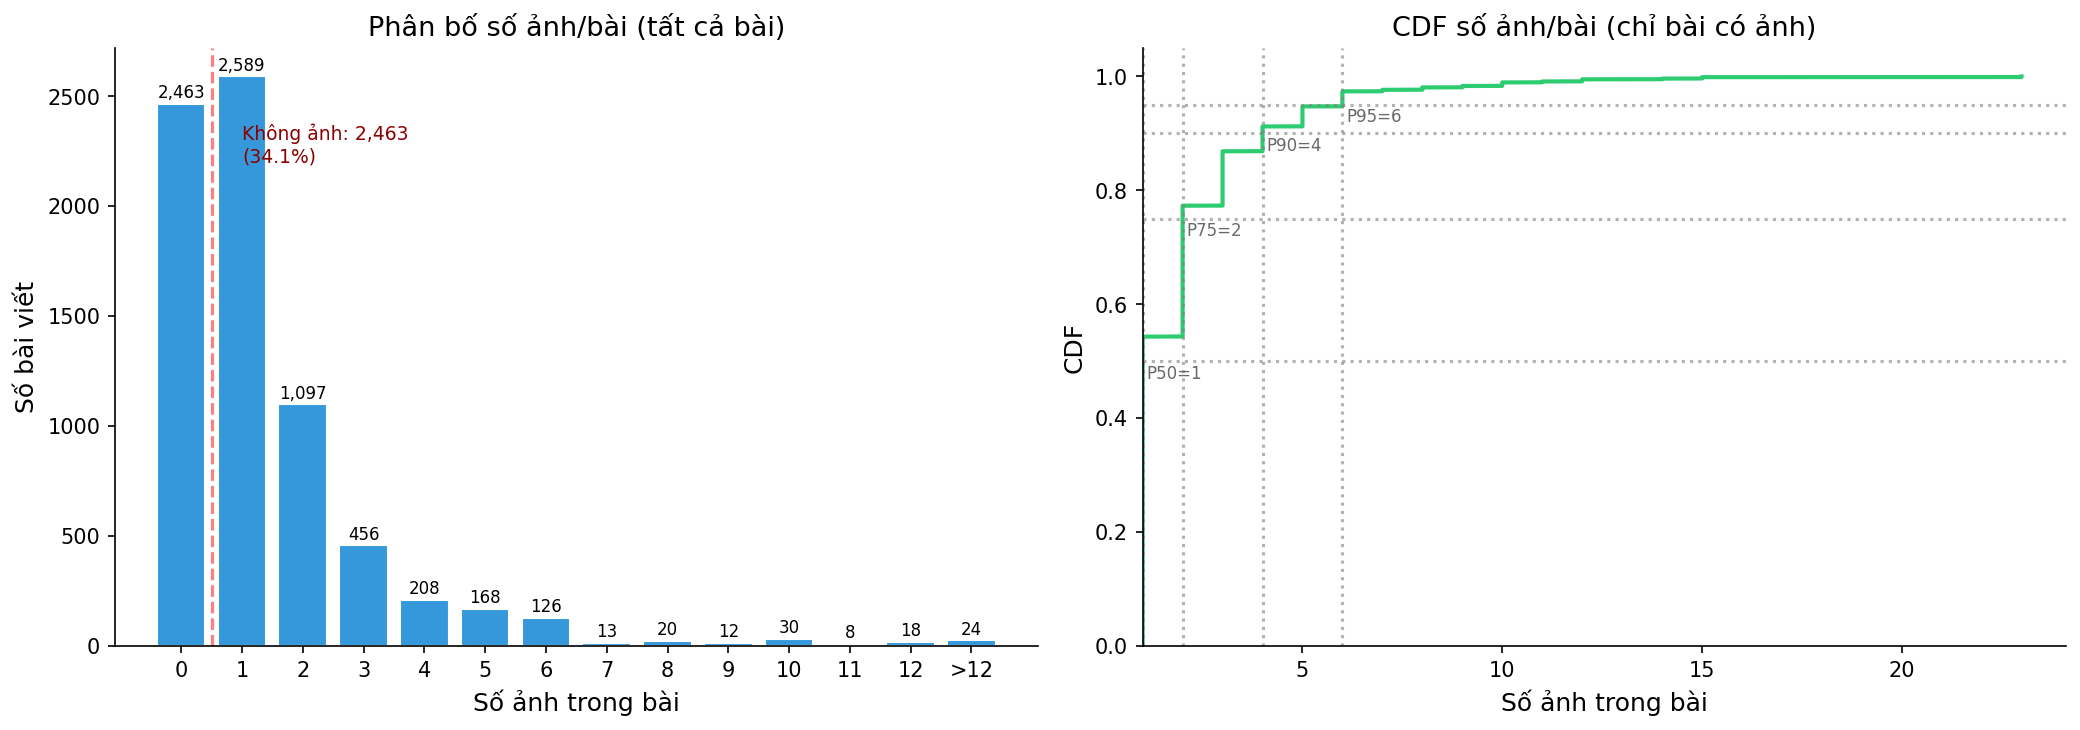

Saved: fig_d3_images_per_article.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot A: histogram of images per article (all, incl. 0) ---
img_counts = df_art["image_count"].values
count_dist = Counter(img_counts)
max_show = 12
x_vals = list(range(min(max_show + 1, max(count_dist.keys()) + 1)))
y_vals = [count_dist.get(k, 0) for k in x_vals]
# Lump everything > max_show into last bin label
if max(count_dist.keys()) > max_show:
    rest = sum(v for k, v in count_dist.items() if k > max_show)
    x_vals.append(f">{max_show}")
    y_vals.append(rest)

x_pos = np.arange(len(x_vals))
bars = axes[0].bar(x_pos, y_vals, color="#3498db", edgecolor="white")
for bar, val in zip(bars, y_vals):
    if val > 0:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f"{val:,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(v) for v in x_vals])
axes[0].set_xlabel("Số ảnh trong bài")
axes[0].set_ylabel("Số bài viết")
axes[0].set_title("Phân bố số ảnh/bài (tất cả bài)")

# Stats annotation
no_img = count_dist.get(0, 0)
axes[0].axvline(x=0.5, color="red", linestyle="--", alpha=0.5)
axes[0].text(
    1,
    max(y_vals) * 0.85,
    f"Không ảnh: {no_img:,}\n({no_img/len(df_art)*100:.1f}%)",
    fontsize=9,
    color="darkred",
)

# --- Plot B: CDF of images per article (excluding 0) ---
has_img = df_art[df_art.image_count > 0]["image_count"].values
sorted_vals = np.sort(has_img)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color="#2ecc71", linewidth=2)
for pct in [0.5, 0.75, 0.9, 0.95]:
    val = np.percentile(sorted_vals, pct * 100)
    axes[1].axhline(y=pct, color="gray", linestyle=":", alpha=0.6)
    axes[1].axvline(x=val, color="gray", linestyle=":", alpha=0.6)
    axes[1].text(
        val + 0.1, pct - 0.03, f"P{int(pct*100)}={val:.0f}", fontsize=8, color="dimgray"
    )
axes[1].set_xlabel("Số ảnh trong bài")
axes[1].set_ylabel("CDF")
axes[1].set_title("CDF số ảnh/bài (chỉ bài có ảnh)")
axes[1].set_xlim(left=1)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d3_images_per_article.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d3_images_per_article.png")

## 6. Phân tích độ dài caption


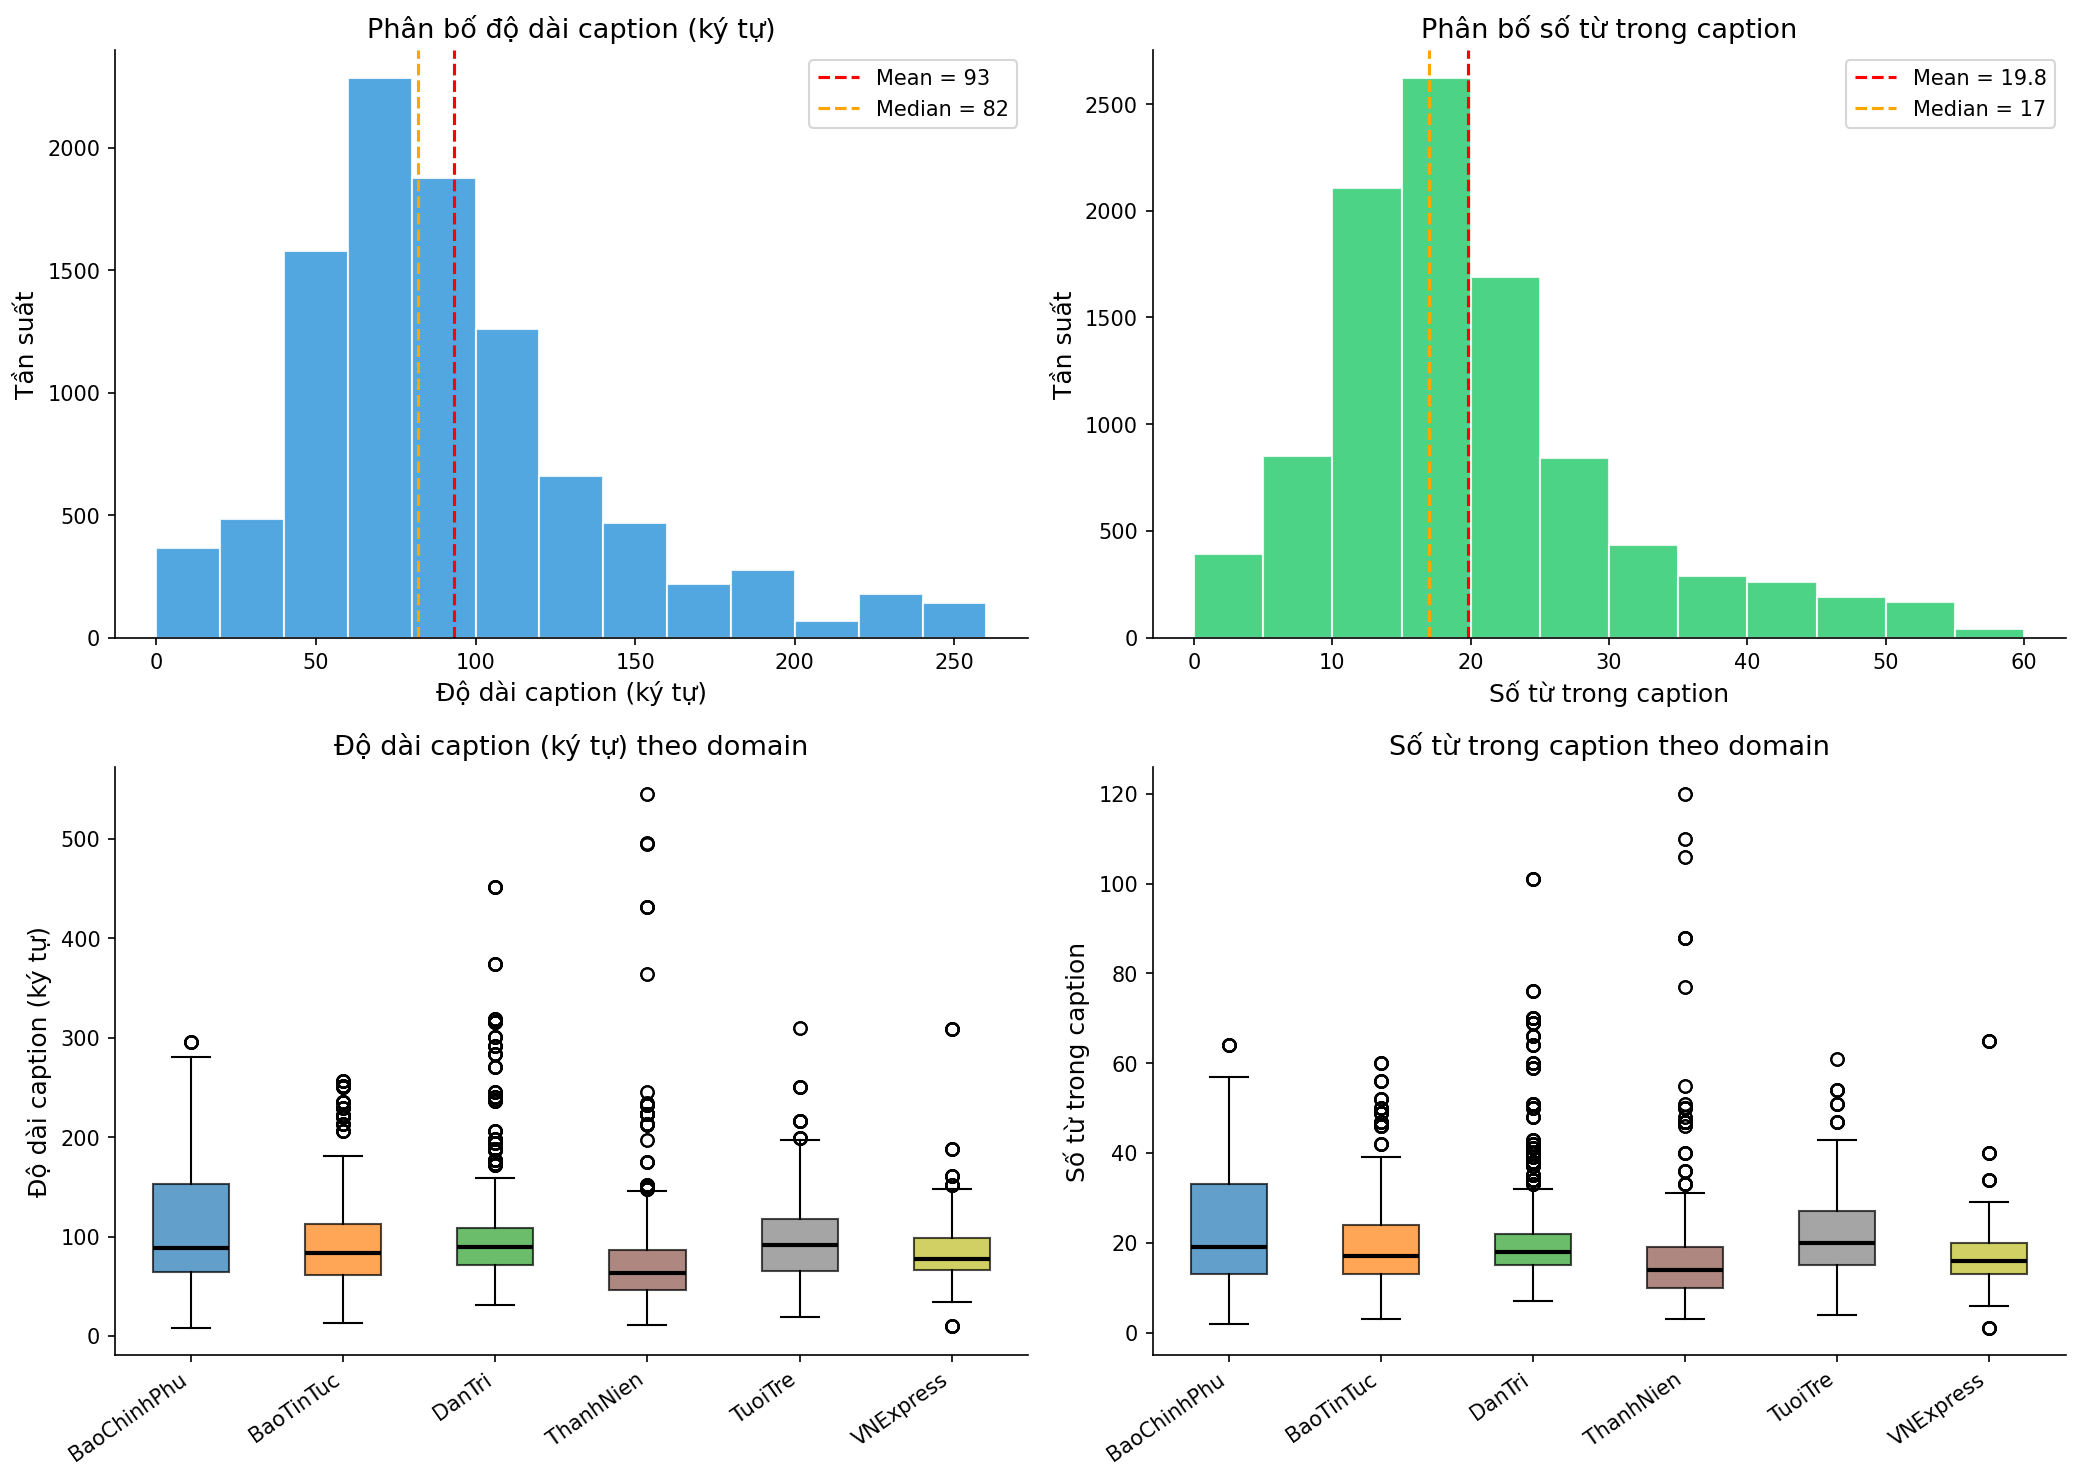

Saved: fig_d4_caption_length.png


In [ ]:
df_cap = df_img[df_img.has_caption].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- A: Caption char length histogram ---
bins_c = np.arange(0, df_cap.cap_chars.quantile(0.99) + 20, 20)
axes[0, 0].hist(
    df_cap["cap_chars"], bins=bins_c, color="#3498db", edgecolor="white", alpha=0.85
)
axes[0, 0].axvline(
    df_cap.cap_chars.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df_cap.cap_chars.mean():.0f}",
)
axes[0, 0].axvline(
    df_cap.cap_chars.median(),
    color="orange",
    linestyle="--",
    label=f"Median = {df_cap.cap_chars.median():.0f}",
)
axes[0, 0].set_xlabel("Độ dài caption (ký tự)")
axes[0, 0].set_ylabel("Tần suất")
axes[0, 0].set_title("Phân bố độ dài caption (ký tự)")
axes[0, 0].legend()

# --- B: Caption word count histogram ---
bins_w = np.arange(0, df_cap.cap_words.quantile(0.99) + 5, 5)
axes[0, 1].hist(
    df_cap["cap_words"], bins=bins_w, color="#2ecc71", edgecolor="white", alpha=0.85
)
axes[0, 1].axvline(
    df_cap.cap_words.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df_cap.cap_words.mean():.1f}",
)
axes[0, 1].axvline(
    df_cap.cap_words.median(),
    color="orange",
    linestyle="--",
    label=f"Median = {df_cap.cap_words.median():.0f}",
)
axes[0, 1].set_xlabel("Số từ trong caption")
axes[0, 1].set_ylabel("Tần suất")
axes[0, 1].set_title("Phân bố số từ trong caption")
axes[0, 1].legend()

# --- C: Box plot caption char length by domain ---
domain_order = sorted(df_cap["domain"].unique())
domain_labels = [DOMAIN_SHORT.get(d, d) for d in domain_order]
data_by_domain = [df_cap[df_cap.domain == d]["cap_chars"].values for d in domain_order]
bp = axes[1, 0].boxplot(
    data_by_domain,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, d in zip(bp["boxes"], domain_order):
    patch.set_facecolor(DOMAIN_COLORS.get(d, "#999"))
    patch.set_alpha(0.7)
axes[1, 0].set_xticklabels(domain_labels, rotation=35, ha="right")
axes[1, 0].set_ylabel("Độ dài caption (ký tự)")
axes[1, 0].set_title("Độ dài caption (ký tự) theo domain")

# --- D: Box plot caption word count by domain ---
data_words = [df_cap[df_cap.domain == d]["cap_words"].values for d in domain_order]
bp2 = axes[1, 1].boxplot(
    data_words,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, d in zip(bp2["boxes"], domain_order):
    patch.set_facecolor(DOMAIN_COLORS.get(d, "#999"))
    patch.set_alpha(0.7)
axes[1, 1].set_xticklabels(domain_labels, rotation=35, ha="right")
axes[1, 1].set_ylabel("Số từ trong caption")
axes[1, 1].set_title("Số từ trong caption theo domain")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d4_caption_length.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d4_caption_length.png")

## 7. Thống kê caption theo domain


In [ ]:
# Detailed caption stats per domain
cap_stats = []
for d in sorted(df_img["domain"].unique()):
    sub_a = df_art[df_art.domain == d]
    sub_i = df_img[df_img.domain == d]
    sub_c = sub_i[sub_i.has_caption]
    cap_stats.append(
        {
            "Domain": DOMAIN_SHORT.get(d, d),
            "Bài viết": len(sub_a),
            "Bài có ảnh (%)": f"{sub_a.has_images.mean()*100:.1f}%",
            "Tổng ảnh (ref)": len(sub_i),
            "File ảnh duy nhất": sub_i["path"].nunique(),
            "Ảnh có caption (%)": (
                f"{sub_i.has_caption.mean()*100:.1f}%" if len(sub_i) else "—"
            ),
            "TB char caption": f"{sub_c.cap_chars.mean():.0f}" if len(sub_c) else "—",
            "TB từ caption": f"{sub_c.cap_words.mean():.1f}" if len(sub_c) else "—",
            "Max char": f"{sub_c.cap_chars.max()}" if len(sub_c) else "—",
            "TB ảnh/bài": f"{sub_a.image_count.mean():.2f}",
        }
    )

df_cap_stats = pd.DataFrame(cap_stats).set_index("Domain")
display(df_cap_stats.style.set_caption("Bảng 2: Thống kê caption chi tiết theo domain"))

,Bài viết,Bài có ảnh (%),Tổng ảnh (ref),File ảnh duy nhất,Ảnh có caption (%),TB char caption,TB từ caption,Max char,TB ảnh/bài
Domain,,,,,,,,,
BaoChinhPhu,1222,94.4%,2303,292,100.0%,107,23.0,296,1.88
BaoTinTuc,807,92.6%,1291,184,100.0%,92,19.2,256,1.60
DanTri,864,99.3%,2220,328,100.0%,99,20.6,451,2.57
ThanhNien,928,98.7%,2182,273,100.0%,75,16.2,545,2.35
TuoiTre,703,97.2%,1285,203,100.0%,95,21.0,310,1.83
VNExpress,500,82.2%,663,111,100.0%,85,17.0,309,1.33


## 8. Tỉ lệ ảnh–caption khớp (Image–Caption Matching Coverage)


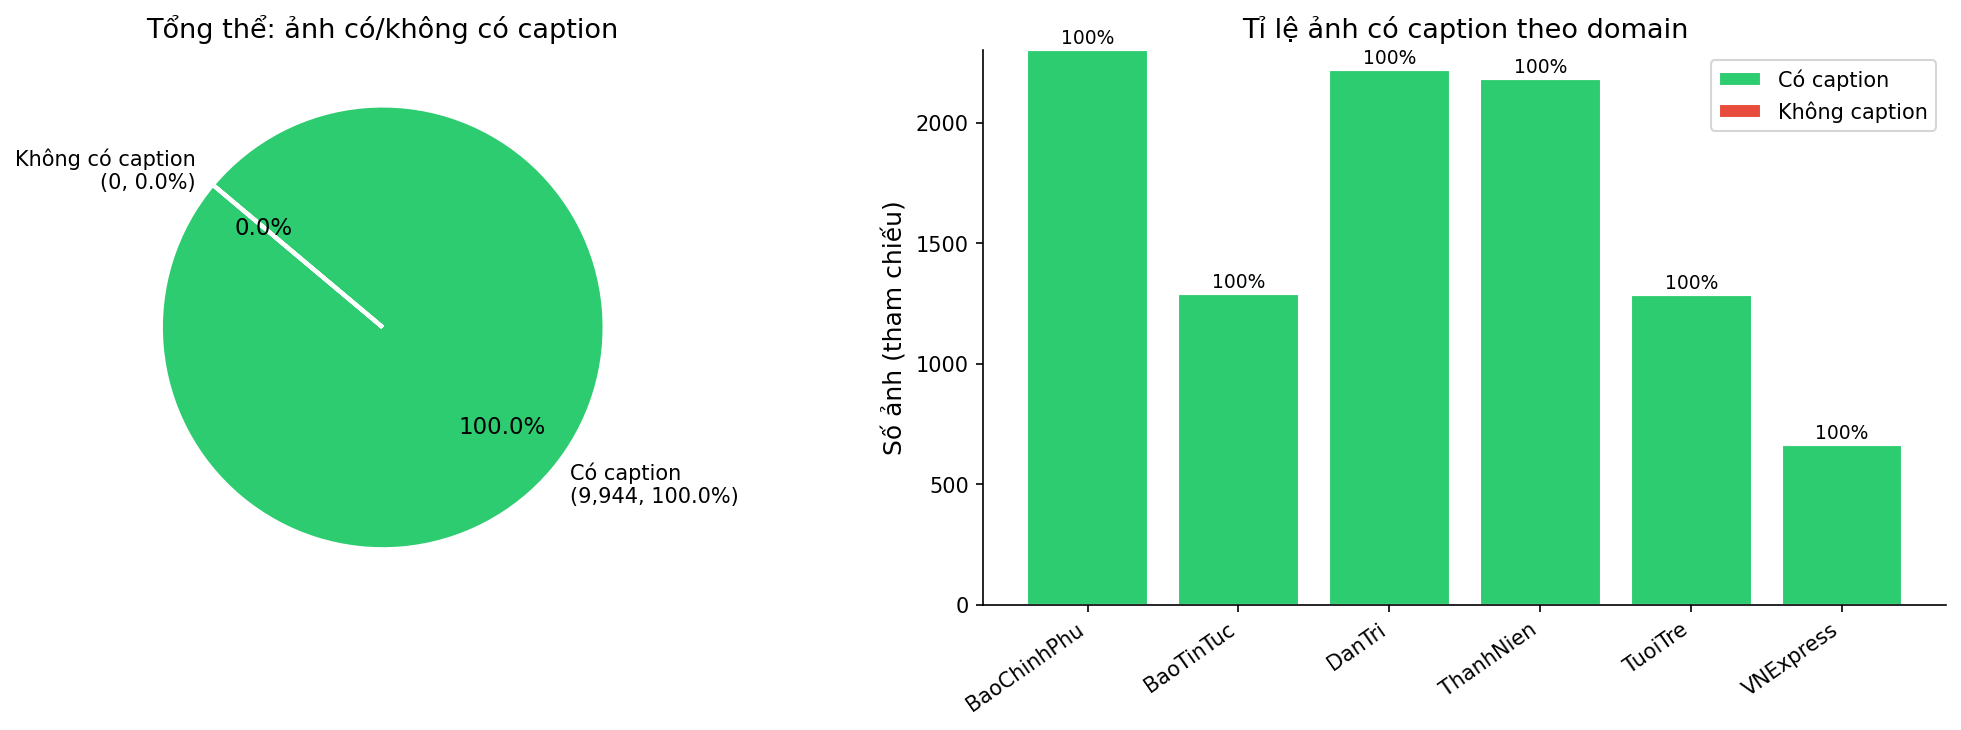

Saved: fig_d5_image_caption_coverage.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- A: Overall pie: has caption vs no caption ---
n_cap = df_img.has_caption.sum()
n_no_cap = len(df_img) - n_cap

wedge_data = [n_cap, n_no_cap]
wedge_labels = [
    f"Có caption\n({n_cap:,}, {n_cap/len(df_img)*100:.1f}%)",
    f"Không có caption\n({n_no_cap:,}, {n_no_cap/len(df_img)*100:.1f}%)",
]
colors_pie = ["#2ecc71", "#e74c3c"]

axes[0].pie(
    wedge_data,
    labels=wedge_labels,
    colors=colors_pie,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.70,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
axes[0].set_title("Tổng thể: ảnh có/không có caption")

# --- B: Stacked bar by domain ---
domain_order = sorted(df_img["domain"].unique())
has_caps = [df_img[df_img.domain == d].has_caption.sum() for d in domain_order]
no_caps = [len(df_img[df_img.domain == d]) - h for h, d in zip(has_caps, domain_order)]
short_labels = [DOMAIN_SHORT.get(d, d) for d in domain_order]
x = np.arange(len(domain_order))

axes[1].bar(x, has_caps, color="#2ecc71", label="Có caption", edgecolor="white")
axes[1].bar(
    x,
    no_caps,
    bottom=has_caps,
    color="#e74c3c",
    label="Không caption",
    edgecolor="white",
)

for i, (hc, nc) in enumerate(zip(has_caps, no_caps)):
    total = hc + nc
    if total > 0:
        axes[1].text(
            i, total + 10, f"{hc/total*100:.0f}%", ha="center", va="bottom", fontsize=9
        )

axes[1].set_xticks(x)
axes[1].set_xticklabels(short_labels, rotation=35, ha="right")
axes[1].set_ylabel("Số ảnh (tham chiếu)")
axes[1].set_title("Tỉ lệ ảnh có caption theo domain")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig_d5_image_caption_coverage.png", bbox_inches="tight", dpi=150
)
plt.show()
print("Saved: fig_d5_image_caption_coverage.png")

## 9. Mức độ tái sử dụng ảnh (Image Reuse)


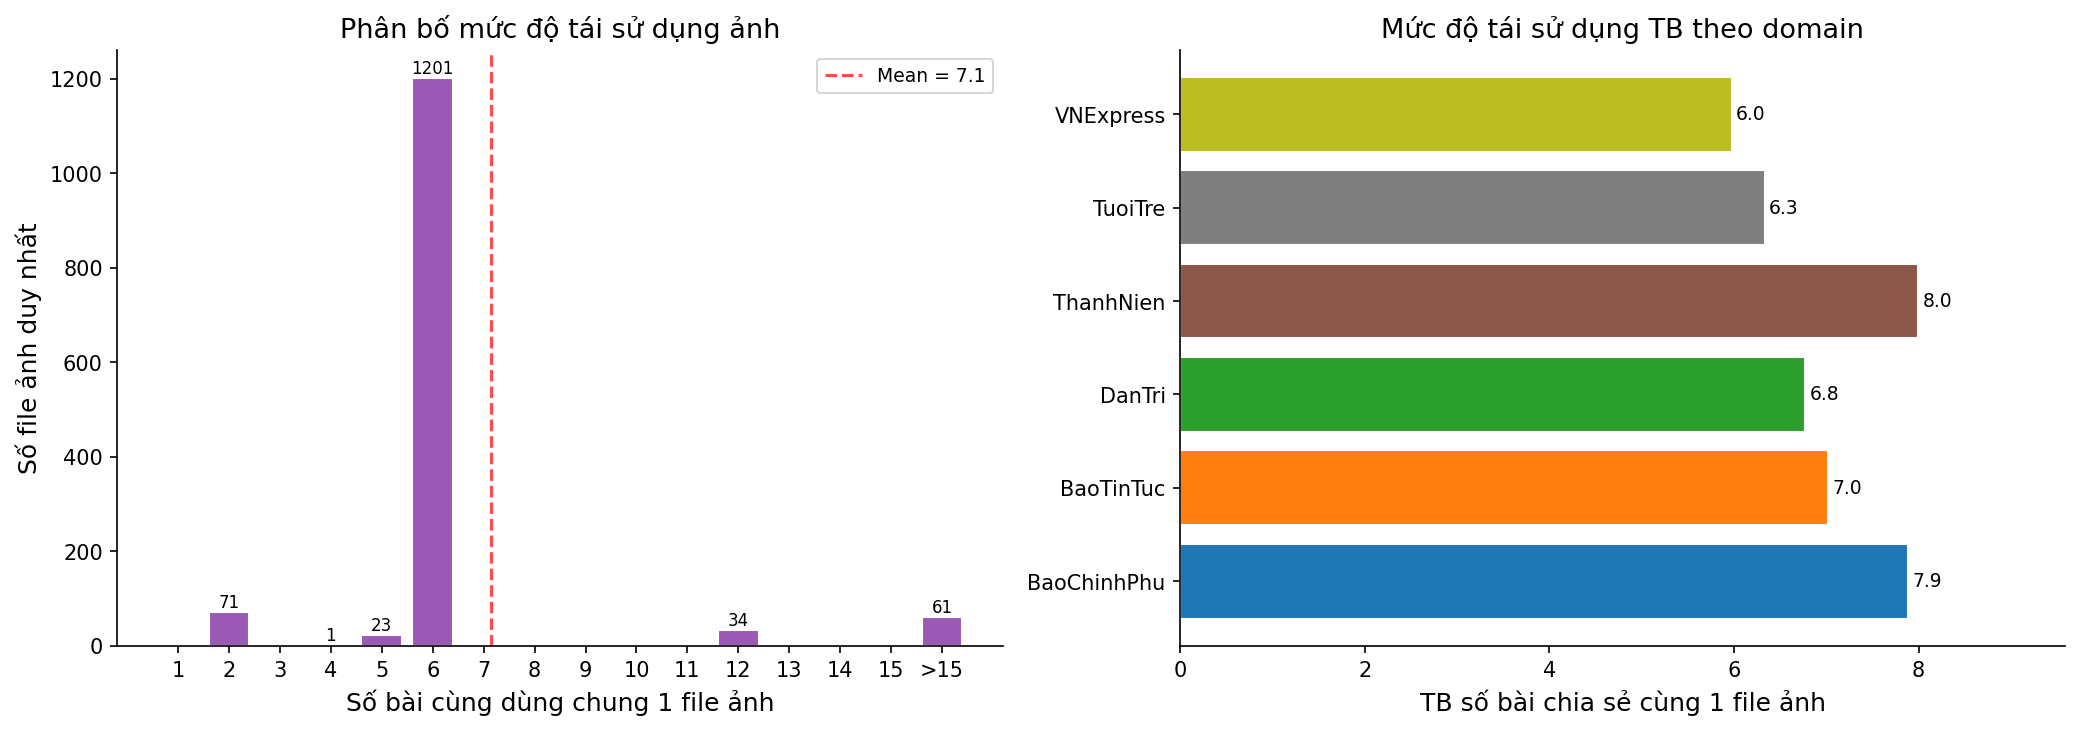

Saved: fig_d6_image_reuse.png


In [ ]:
path_counts = df_img["path"].value_counts()  # how many refs per unique path

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- A: Distribution of reuse count ---
reuse_dist = Counter(path_counts.values)
max_show_r = 15
x_vals_r = list(range(1, min(max_show_r + 1, max(reuse_dist.keys()) + 1)))
y_vals_r = [reuse_dist.get(k, 0) for k in x_vals_r]
rest_r = sum(v for k, v in reuse_dist.items() if k > max_show_r)
if rest_r:
    x_vals_r.append(f">{max_show_r}")
    y_vals_r.append(rest_r)

x_pos_r = np.arange(len(x_vals_r))
bars = axes[0].bar(x_pos_r, y_vals_r, color="#9b59b6", edgecolor="white")
for bar, val in zip(bars, y_vals_r):
    if val > 0:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
axes[0].set_xticks(x_pos_r)
axes[0].set_xticklabels([str(v) for v in x_vals_r])
axes[0].set_xlabel("Số bài cùng dùng chung 1 file ảnh")
axes[0].set_ylabel("Số file ảnh duy nhất")
axes[0].set_title("Phân bố mức độ tái sử dụng ảnh")

# Stats annotation
mean_reuse = path_counts.mean()
axes[0].axvline(
    x=mean_reuse - 1,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Mean = {mean_reuse:.1f}",
)
axes[0].legend(fontsize=9)

# --- B: Reuse by domain ---
domain_reuse = df_img.groupby("domain")["path"].apply(lambda x: x.value_counts().mean())
domain_reuse_sorted = domain_reuse.reindex(sorted(domain_reuse.index))
colors_r = [DOMAIN_COLORS.get(d, "#999") for d in domain_reuse_sorted.index]
short_r = [DOMAIN_SHORT.get(d, d) for d in domain_reuse_sorted.index]

axes[1].barh(short_r, domain_reuse_sorted.values, color=colors_r, edgecolor="white")
for i, v in enumerate(domain_reuse_sorted.values):
    axes[1].text(v + 0.05, i, f"{v:.1f}", va="center", fontsize=9)
axes[1].set_xlabel("TB số bài chia sẻ cùng 1 file ảnh")
axes[1].set_title("Mức độ tái sử dụng TB theo domain")
axes[1].set_xlim(0, domain_reuse_sorted.max() * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d6_image_reuse.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d6_image_reuse.png")

## 10. Kích thước file ảnh


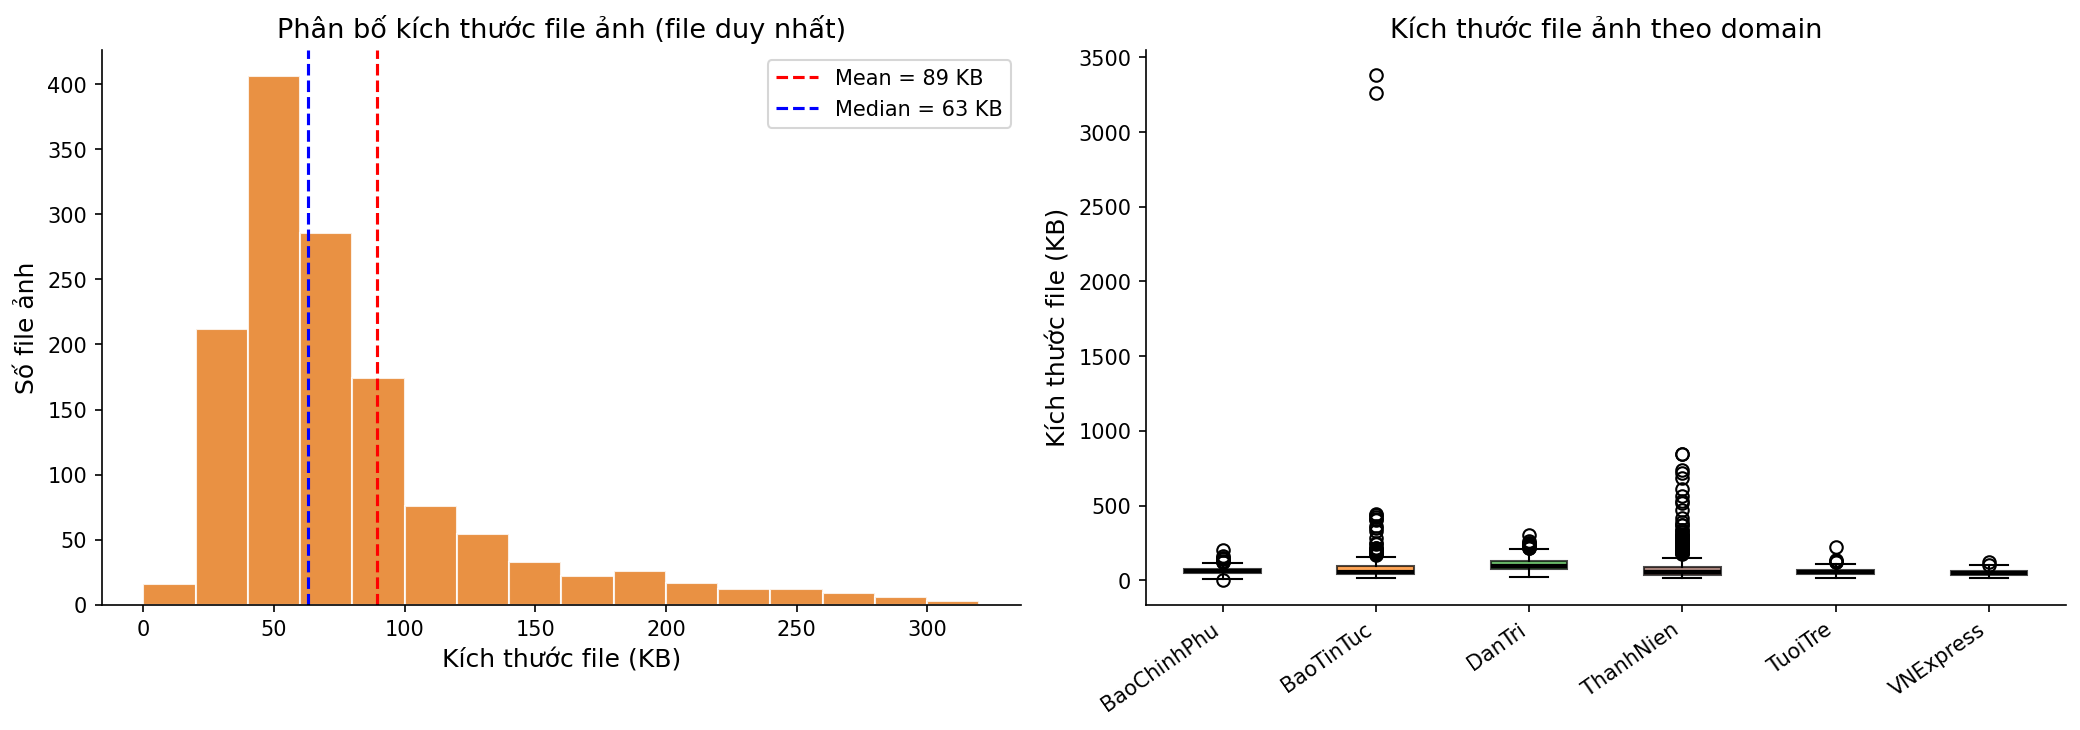

Saved: fig_d7_file_size.png


In [ ]:
# Unique files only (to avoid counting duplicates)
df_unique_imgs = df_img.drop_duplicates("path").copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- A: File size histogram ---
bins_s = np.arange(0, df_unique_imgs.file_size_kb.quantile(0.98) + 20, 20)
axes[0].hist(
    df_unique_imgs["file_size_kb"],
    bins=bins_s,
    color="#e67e22",
    edgecolor="white",
    alpha=0.85,
)
axes[0].axvline(
    df_unique_imgs.file_size_kb.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df_unique_imgs.file_size_kb.mean():.0f} KB",
)
axes[0].axvline(
    df_unique_imgs.file_size_kb.median(),
    color="blue",
    linestyle="--",
    label=f"Median = {df_unique_imgs.file_size_kb.median():.0f} KB",
)
axes[0].set_xlabel("Kích thước file (KB)")
axes[0].set_ylabel("Số file ảnh")
axes[0].set_title("Phân bố kích thước file ảnh (file duy nhất)")
axes[0].legend()

# --- B: Box plot by domain ---
domain_order = sorted(df_unique_imgs["domain"].unique())
data_sizes = [
    df_unique_imgs[df_unique_imgs.domain == d]["file_size_kb"].values
    for d in domain_order
]
short_d = [DOMAIN_SHORT.get(d, d) for d in domain_order]
bp = axes[1].boxplot(
    data_sizes, patch_artist=True, medianprops=dict(color="black", linewidth=2)
)
for patch, d in zip(bp["boxes"], domain_order):
    patch.set_facecolor(DOMAIN_COLORS.get(d, "#999"))
    patch.set_alpha(0.7)
axes[1].set_xticklabels(short_d, rotation=35, ha="right")
axes[1].set_ylabel("Kích thước file (KB)")
axes[1].set_title("Kích thước file ảnh theo domain")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d7_file_size.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d7_file_size.png")

## 11. Kích thước (resolution) hình ảnh

> **Lưu ý:** Do latency Google Drive, kích thước được đo trên **mẫu 10 ảnh/domain** (stratified, seed=42) — đủ đại diện cho phân bố tổng thể.


In [ ]:
import struct, random
from pathlib import Path


def _read_jpeg_wh(path):
    """Read JPEG width/height by scanning header only (no full decode)."""
    try:
        with open(path, "rb") as f:
            if f.read(2) != b"\xff\xd8":
                return None, None
            while True:
                b = f.read(1)
                if b != b"\xff":
                    break
                marker = f.read(1)
                if marker in (b"\xc0", b"\xc2"):
                    f.read(3)
                    h = struct.unpack(">H", f.read(2))[0]
                    w = struct.unpack(">H", f.read(2))[0]
                    return w, h
                n = struct.unpack(">H", f.read(2))[0]
                f.seek(n - 2, 1)
    except Exception:
        return None, None


# Stratified sample: up to SAMPLE_PER_DOMAIN per domain (fast enough)
SAMPLE_PER_DOMAIN = 10
random.seed(42)

sample_paths, sample_domains = [], []
for d in sorted(df_unique_imgs["domain"].unique()):
    rows_d = df_unique_imgs[df_unique_imgs.domain == d]["path"].tolist()
    chosen = random.sample(rows_d, min(SAMPLE_PER_DOMAIN, len(rows_d)))
    sample_paths.extend(chosen)
    sample_domains.extend([d] * len(chosen))

print(
    f"Đang đọc dimensions từ {len(sample_paths)} ảnh mẫu ({SAMPLE_PER_DOMAIN}/domain)…"
)
widths, heights, domains_dim, paths_dim = [], [], [], []

for path_rel, dom in zip(sample_paths, sample_domains):
    full_path = DATA_ROOT / "data" / path_rel
    w, h = _read_jpeg_wh(str(full_path))
    if w and h:
        widths.append(w)
        heights.append(h)
        domains_dim.append(dom)
        paths_dim.append(path_rel)

df_dims = pd.DataFrame(
    {
        "path": paths_dim,
        "domain": domains_dim,
        "width": widths,
        "height": heights,
    }
)
df_dims["aspect_ratio"] = df_dims["width"] / df_dims["height"]
df_dims["megapixels"] = (df_dims["width"] * df_dims["height"]) / 1e6

print(
    f"✅ Đọc được {len(df_dims):,} ảnh mẫu  (lưu ý: thống kê dựa trên mẫu {SAMPLE_PER_DOMAIN}/domain)"
)
print(
    f"   Width  : mean={df_dims.width.mean():.0f}, median={df_dims.width.median():.0f}, min={df_dims.width.min()}, max={df_dims.width.max()}"
)
print(
    f"   Height : mean={df_dims.height.mean():.0f}, median={df_dims.height.median():.0f}, min={df_dims.height.min()}, max={df_dims.height.max()}"
)
print(
    f"   AR     : mean={df_dims.aspect_ratio.mean():.2f}, median={df_dims.aspect_ratio.median():.2f}"
)

Đang đọc dimensions từ 60 ảnh mẫu (10/domain)…
✅ Đọc được 60 ảnh mẫu  (lưu ý: thống kê dựa trên mẫu 10/domain)
   Width  : mean=824, median=730, min=349, max=1920
   Height : mean=556, median=487, min=325, max=1257
   AR     : mean=1.50, median=1.50


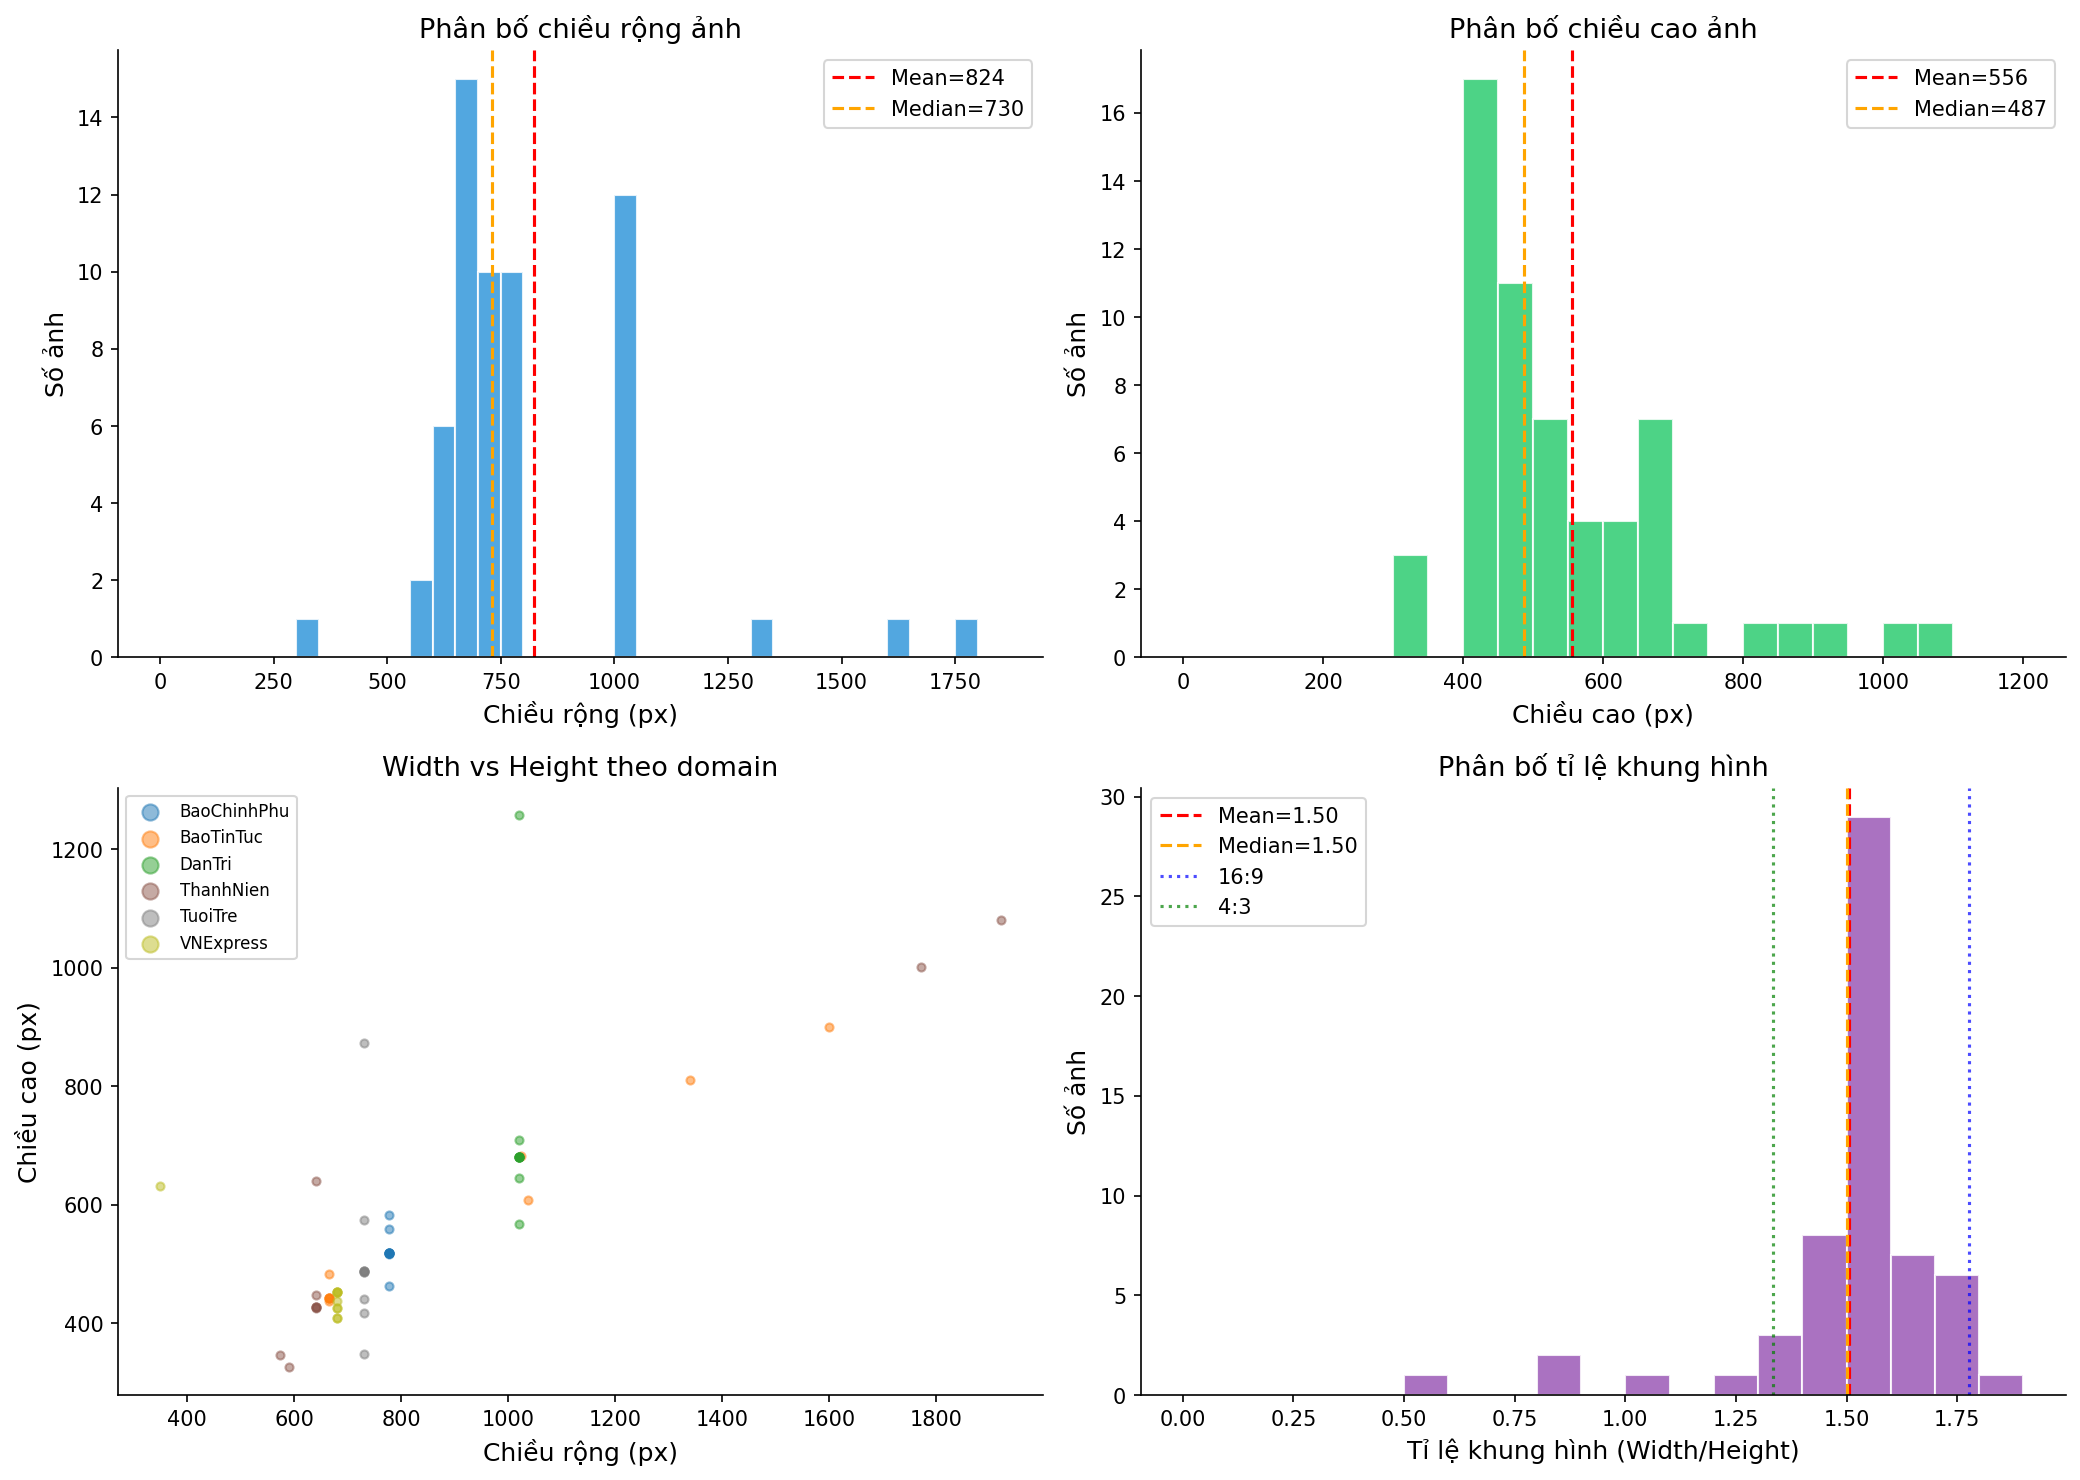

Saved: fig_d8_image_dimensions.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- A: Width distribution ---
bins_w = np.arange(0, df_dims.width.quantile(0.99) + 50, 50)
axes[0, 0].hist(
    df_dims["width"], bins=bins_w, color="#3498db", edgecolor="white", alpha=0.85
)
axes[0, 0].axvline(
    df_dims.width.mean(),
    color="red",
    linestyle="--",
    label=f"Mean={df_dims.width.mean():.0f}",
)
axes[0, 0].axvline(
    df_dims.width.median(),
    color="orange",
    linestyle="--",
    label=f"Median={df_dims.width.median():.0f}",
)
axes[0, 0].set_xlabel("Chiều rộng (px)")
axes[0, 0].set_ylabel("Số ảnh")
axes[0, 0].set_title("Phân bố chiều rộng ảnh")
axes[0, 0].legend()

# --- B: Height distribution ---
bins_h = np.arange(0, df_dims.height.quantile(0.99) + 50, 50)
axes[0, 1].hist(
    df_dims["height"], bins=bins_h, color="#2ecc71", edgecolor="white", alpha=0.85
)
axes[0, 1].axvline(
    df_dims.height.mean(),
    color="red",
    linestyle="--",
    label=f"Mean={df_dims.height.mean():.0f}",
)
axes[0, 1].axvline(
    df_dims.height.median(),
    color="orange",
    linestyle="--",
    label=f"Median={df_dims.height.median():.0f}",
)
axes[0, 1].set_xlabel("Chiều cao (px)")
axes[0, 1].set_ylabel("Số ảnh")
axes[0, 1].set_title("Phân bố chiều cao ảnh")
axes[0, 1].legend()

# --- C: Scatter plot width vs height (colored by domain) ---
for d in sorted(df_dims["domain"].unique()):
    sub = df_dims[df_dims.domain == d]
    axes[1, 0].scatter(
        sub.width,
        sub.height,
        c=DOMAIN_COLORS.get(d, "#999"),
        alpha=0.5,
        s=15,
        label=DOMAIN_SHORT.get(d, d),
    )
axes[1, 0].set_xlabel("Chiều rộng (px)")
axes[1, 0].set_ylabel("Chiều cao (px)")
axes[1, 0].set_title("Width vs Height theo domain")
axes[1, 0].legend(markerscale=2, fontsize=8)

# --- D: Aspect ratio distribution ---
bins_ar = np.arange(0, min(df_dims.aspect_ratio.quantile(0.98) + 0.1, 4.0), 0.1)
axes[1, 1].hist(
    df_dims["aspect_ratio"],
    bins=bins_ar,
    color="#9b59b6",
    edgecolor="white",
    alpha=0.85,
)
axes[1, 1].axvline(
    df_dims.aspect_ratio.mean(),
    color="red",
    linestyle="--",
    label=f"Mean={df_dims.aspect_ratio.mean():.2f}",
)
axes[1, 1].axvline(
    df_dims.aspect_ratio.median(),
    color="orange",
    linestyle="--",
    label=f"Median={df_dims.aspect_ratio.median():.2f}",
)
axes[1, 1].axvline(16 / 9, color="blue", linestyle=":", alpha=0.7, label="16:9")
axes[1, 1].axvline(4 / 3, color="green", linestyle=":", alpha=0.7, label="4:3")
axes[1, 1].set_xlabel("Tỉ lệ khung hình (Width/Height)")
axes[1, 1].set_ylabel("Số ảnh")
axes[1, 1].set_title("Phân bố tỉ lệ khung hình")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d8_image_dimensions.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d8_image_dimensions.png")

## 12. Resolution trung bình theo domain


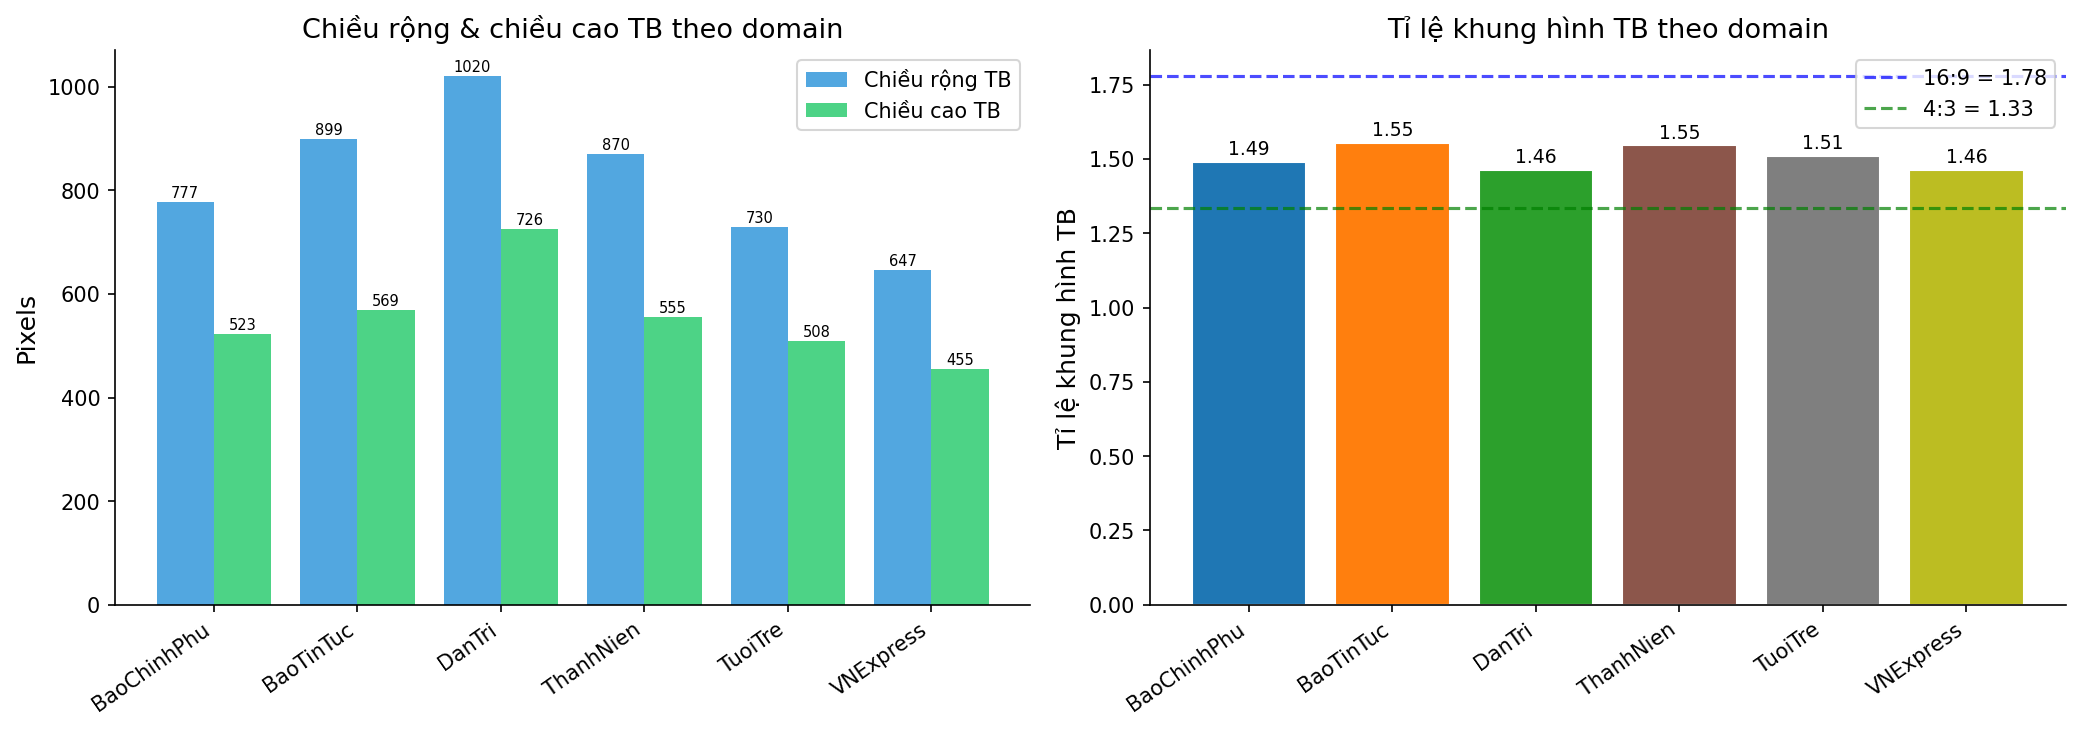

Saved: fig_d9_resolution_by_domain.png


In [ ]:
dim_by_domain = (
    df_dims.groupby("domain")
    .agg(
        mean_width=("width", "mean"),
        mean_height=("height", "mean"),
        mean_ar=("aspect_ratio", "mean"),
        count=("path", "count"),
    )
    .reindex(sorted(df_dims.domain.unique()))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domains_d = dim_by_domain.index.tolist()
short_d2 = [DOMAIN_SHORT.get(d, d) for d in domains_d]
colors_d2 = [DOMAIN_COLORS.get(d, "#999") for d in domains_d]
x2 = np.arange(len(domains_d))
w2 = 0.4

# --- A: Width and Height grouped bars ---
b1 = axes[0].bar(
    x2 - w2 / 2,
    dim_by_domain.mean_width,
    w2,
    label="Chiều rộng TB",
    color="#3498db",
    alpha=0.85,
)
b2 = axes[0].bar(
    x2 + w2 / 2,
    dim_by_domain.mean_height,
    w2,
    label="Chiều cao TB",
    color="#2ecc71",
    alpha=0.85,
)
for bar, v in zip(b1, dim_by_domain.mean_width):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{v:.0f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )
for bar, v in zip(b2, dim_by_domain.mean_height):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{v:.0f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )
axes[0].set_xticks(x2)
axes[0].set_xticklabels(short_d2, rotation=35, ha="right")
axes[0].set_ylabel("Pixels")
axes[0].set_title("Chiều rộng & chiều cao TB theo domain")
axes[0].legend()

# --- B: Aspect ratio by domain ---
bars_ar = axes[1].bar(
    short_d2, dim_by_domain.mean_ar, color=colors_d2, edgecolor="white"
)
for bar, v in zip(bars_ar, dim_by_domain.mean_ar):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[1].axhline(y=16 / 9, color="blue", linestyle="--", alpha=0.7, label="16:9 = 1.78")
axes[1].axhline(y=4 / 3, color="green", linestyle="--", alpha=0.7, label="4:3 = 1.33")
axes[1].set_xticklabels(short_d2, rotation=35, ha="right")
axes[1].set_ylabel("Tỉ lệ khung hình TB")
axes[1].set_title("Tỉ lệ khung hình TB theo domain")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig_d9_resolution_by_domain.png", bbox_inches="tight", dpi=150
)
plt.show()
print("Saved: fig_d9_resolution_by_domain.png")

## 13. Bảng tổng hợp tất cả chỉ số


In [ ]:
# ── Comprehensive summary table ──────────────────────────────────────────
summary_rows = []

for d in sorted(df_img["domain"].unique()):
    sub_a = df_art[df_art.domain == d]
    sub_i = df_img[df_img.domain == d]
    sub_c = sub_i[sub_i.has_caption]
    sub_u = df_unique_imgs[df_unique_imgs.domain == d]
    sub_d = df_dims[df_dims.domain == d]

    total_arts = len(sub_a)
    arts_with_img = sub_a.has_images.sum()
    total_refs = len(sub_i)
    unique_files = sub_i["path"].nunique()
    reuse_factor = total_refs / unique_files if unique_files else 0

    summary_rows.append(
        {
            "Domain": DOMAIN_SHORT.get(d, d),
            "Bài viết": total_arts,
            "Bài có ảnh": arts_with_img,
            "% bài có ảnh": (
                f"{arts_with_img/total_arts*100:.1f}%" if total_arts else "—"
            ),
            "Tổng ref ảnh": total_refs,
            "File ảnh DU": unique_files,
            "Hệ số tái SD": f"{reuse_factor:.1f}×",
            "% ảnh có caption": (
                f"{sub_i.has_caption.mean()*100:.1f}%" if total_refs else "—"
            ),
            "TB char caption": f"{sub_c.cap_chars.mean():.0f}" if len(sub_c) else "—",
            "TB từ caption": f"{sub_c.cap_words.mean():.1f}" if len(sub_c) else "—",
            "TB ảnh/bài": f"{sub_a.image_count.mean():.2f}",
            "Size TB (KB)": f"{sub_u.file_size_kb.mean():.0f}" if len(sub_u) else "—",
            "Width TB (px)": f"{sub_d.width.mean():.0f}" if len(sub_d) else "—",
            "Height TB (px)": f"{sub_d.height.mean():.0f}" if len(sub_d) else "—",
            "AR TB": f"{sub_d.aspect_ratio.mean():.2f}" if len(sub_d) else "—",
        }
    )

# ALL row
sub_c_all = df_img[df_img.has_caption]
sub_u_all = df_unique_imgs
total_refs_all = len(df_img)
unique_files_all = df_img["path"].nunique()
summary_rows.append(
    {
        "Domain": "ALL",
        "Bài viết": len(df_art),
        "Bài có ảnh": df_art.has_images.sum(),
        "% bài có ảnh": f"{df_art.has_images.mean()*100:.1f}%",
        "Tổng ref ảnh": total_refs_all,
        "File ảnh DU": unique_files_all,
        "Hệ số tái SD": f"{total_refs_all/unique_files_all:.1f}×",
        "% ảnh có caption": f"{df_img.has_caption.mean()*100:.1f}%",
        "TB char caption": f"{sub_c_all.cap_chars.mean():.0f}",
        "TB từ caption": f"{sub_c_all.cap_words.mean():.1f}",
        "TB ảnh/bài": f"{df_art.image_count.mean():.2f}",
        "Size TB (KB)": f"{sub_u_all.file_size_kb.mean():.0f}",
        "Width TB (px)": f"{df_dims.width.mean():.0f}",
        "Height TB (px)": f"{df_dims.height.mean():.0f}",
        "AR TB": f"{df_dims.aspect_ratio.mean():.2f}",
    }
)

df_summary = pd.DataFrame(summary_rows).set_index("Domain")

display(
    df_summary.style.set_caption(
        "Bảng 3: Tổng hợp toàn bộ chỉ số hình ảnh & caption theo domain"
    ).apply(
        lambda col: [
            "font-weight: bold; background-color: #f0f0f0" if idx == "ALL" else ""
            for idx in col.index
        ]
    )
)

,Bài viết,Bài có ảnh,% bài có ảnh,Tổng ref ảnh,File ảnh DU,Hệ số tái SD,% ảnh có caption,TB char caption,TB từ caption,TB ảnh/bài,Size TB (KB),Width TB (px),Height TB (px),AR TB
Domain,,,,,,,,,,,,,,
BaoChinhPhu,1222,1154,94.4%,2303,292,7.9×,100.0%,107,23.0,1.88,63,777,523,1.49
BaoTinTuc,807,747,92.6%,1291,184,7.0×,100.0%,92,19.2,1.60,125,899,569,1.55
DanTri,864,858,99.3%,2220,328,6.8×,100.0%,99,20.6,2.57,109,1020,726,1.46
ThanhNien,928,916,98.7%,2182,273,8.0×,100.0%,75,16.2,2.35,110,870,555,1.55
TuoiTre,703,683,97.2%,1285,203,6.3×,100.0%,95,21.0,1.83,58,730,508,1.51
VNExpress,500,411,82.2%,663,111,6.0×,100.0%,85,17.0,1.33,50,647,455,1.46
ALL,7232,4769,65.9%,9944,1391,7.1×,100.0%,93,19.8,1.38,89,824,556,1.50


## 14. Heatmap tổng hợp theo domain × split


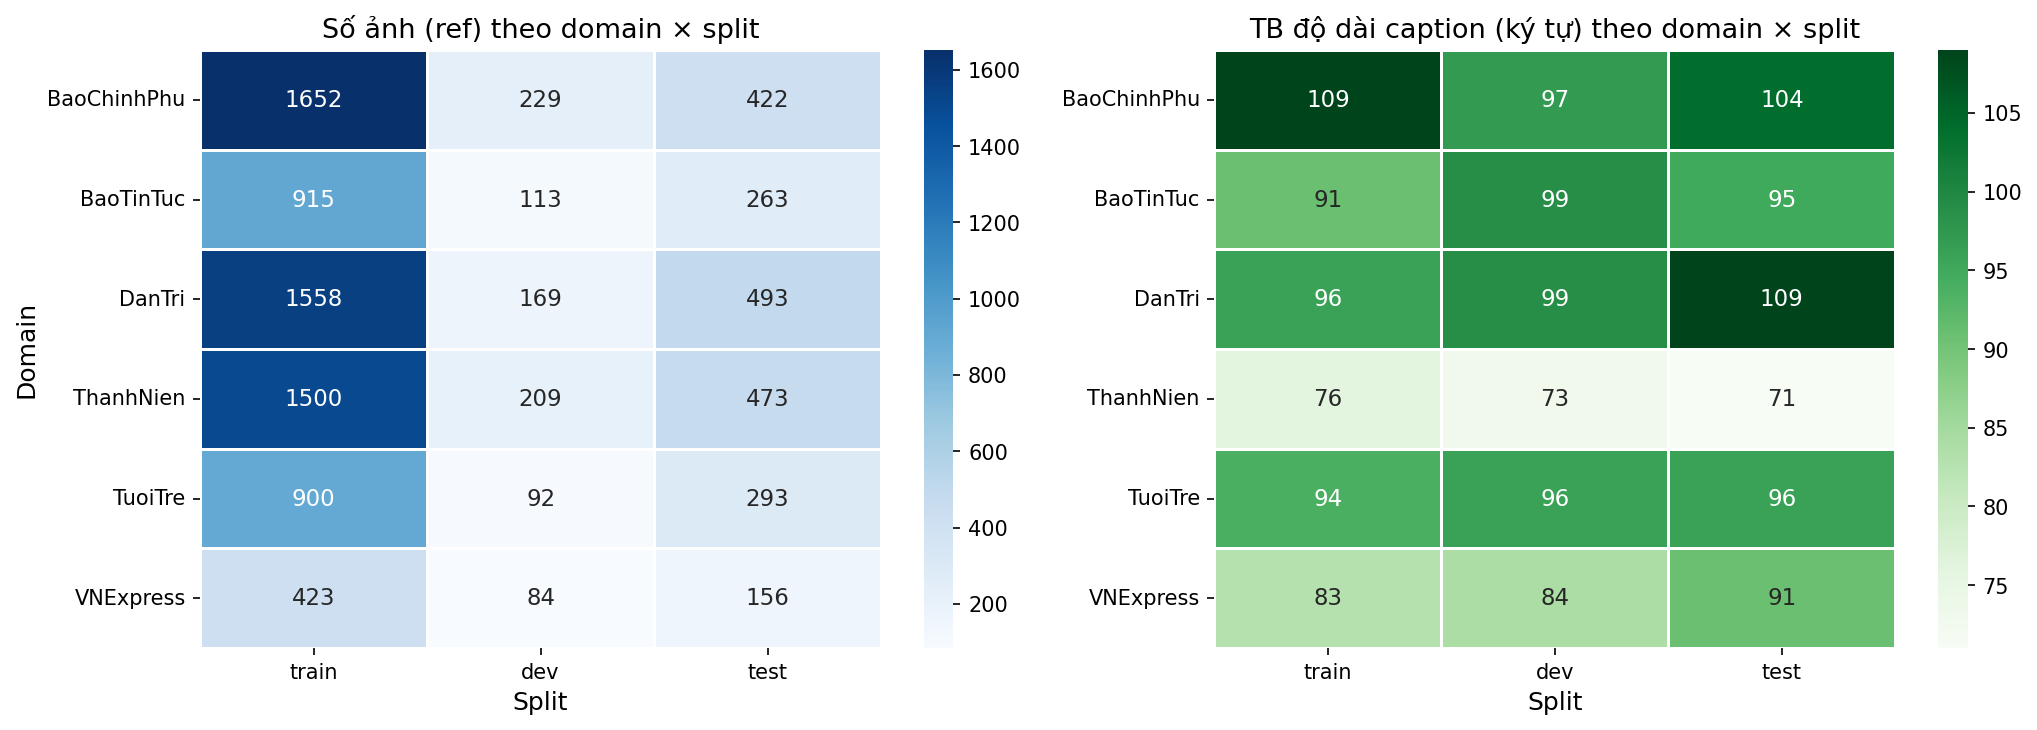

Saved: fig_d10_heatmap_domain_split.png


In [ ]:
# Images per domain × split
pivot = df_img.groupby(["domain", "split"])["path"].count().unstack(fill_value=0)
pivot.index = [DOMAIN_SHORT.get(d, d) for d in pivot.index]
pivot = pivot.reindex(columns=["train", "dev", "test"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- A: Heatmap of image count domain × split ---
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    linewidths=0.5,
    linecolor="white",
)
axes[0].set_title("Số ảnh (ref) theo domain × split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Domain")

# --- B: Heatmap of mean caption length domain × split ---
pivot_cap = (
    df_img[df_img.has_caption]
    .groupby(["domain", "split"])["cap_chars"]
    .mean()
    .unstack(fill_value=0)
)
pivot_cap.index = [DOMAIN_SHORT.get(d, d) for d in pivot_cap.index]
pivot_cap = pivot_cap.reindex(columns=["train", "dev", "test"])
sns.heatmap(
    pivot_cap.round(0).astype(int),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    linewidths=0.5,
    linecolor="white",
)
axes[1].set_title("TB độ dài caption (ký tự) theo domain × split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig_d10_heatmap_domain_split.png", bbox_inches="tight", dpi=150
)
plt.show()
print("Saved: fig_d10_heatmap_domain_split.png")

## 15. CDF độ dài caption


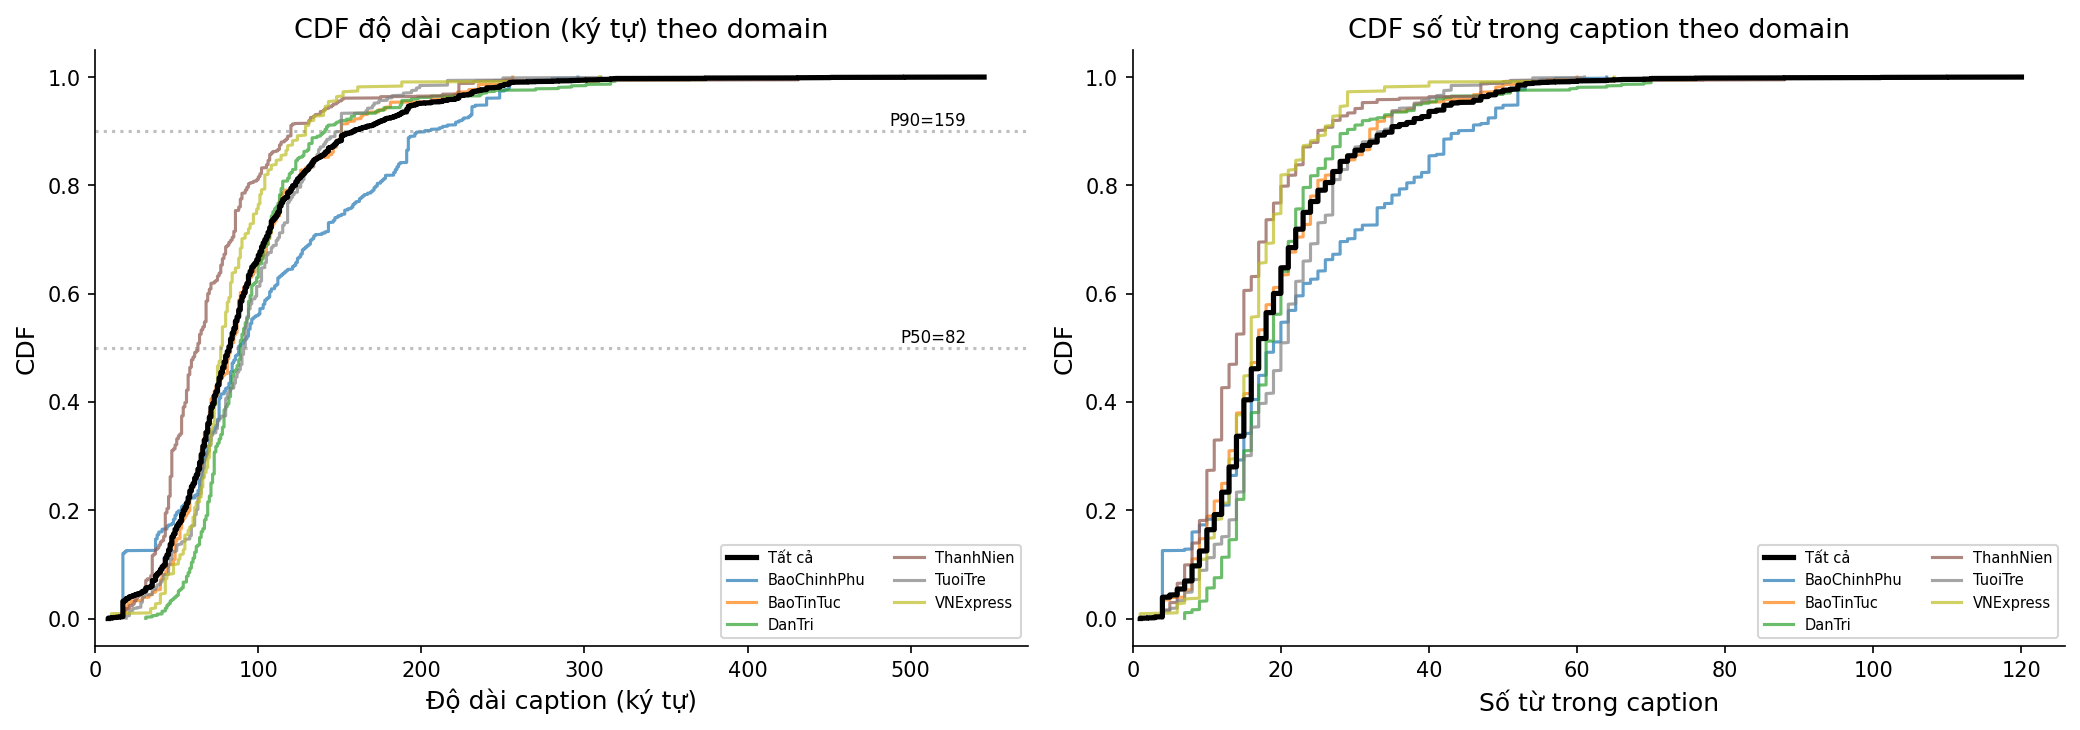

Saved: fig_d11_caption_cdf.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- A: CDF caption chars overall + by domain ---
sorted_all = np.sort(df_cap["cap_chars"].values)
cdf_all = np.arange(1, len(sorted_all) + 1) / len(sorted_all)
axes[0].plot(
    sorted_all, cdf_all, color="black", linewidth=2.5, label="Tất cả", zorder=10
)

for d in sorted(df_cap["domain"].unique()):
    sub = np.sort(df_cap[df_cap.domain == d]["cap_chars"].values)
    if len(sub) == 0:
        continue
    cdf_d = np.arange(1, len(sub) + 1) / len(sub)
    axes[0].plot(
        sub,
        cdf_d,
        color=DOMAIN_COLORS.get(d, "#999"),
        linewidth=1.5,
        alpha=0.7,
        label=DOMAIN_SHORT.get(d, d),
    )

for pct in [0.5, 0.9]:
    val = np.percentile(sorted_all, pct * 100)
    axes[0].axhline(y=pct, color="gray", linestyle=":", alpha=0.5)
    axes[0].text(
        sorted_all.max() * 0.98,
        pct + 0.01,
        f"P{int(pct*100)}={val:.0f}",
        ha="right",
        fontsize=8,
    )

axes[0].set_xlabel("Độ dài caption (ký tự)")
axes[0].set_ylabel("CDF")
axes[0].set_title("CDF độ dài caption (ký tự) theo domain")
axes[0].legend(fontsize=7, ncol=2)
axes[0].set_xlim(left=0)

# --- B: CDF caption words overall + by domain ---
sorted_w = np.sort(df_cap["cap_words"].values)
cdf_w = np.arange(1, len(sorted_w) + 1) / len(sorted_w)
axes[1].plot(sorted_w, cdf_w, color="black", linewidth=2.5, label="Tất cả", zorder=10)

for d in sorted(df_cap["domain"].unique()):
    sub = np.sort(df_cap[df_cap.domain == d]["cap_words"].values)
    if len(sub) == 0:
        continue
    cdf_d = np.arange(1, len(sub) + 1) / len(sub)
    axes[1].plot(
        sub,
        cdf_d,
        color=DOMAIN_COLORS.get(d, "#999"),
        linewidth=1.5,
        alpha=0.7,
        label=DOMAIN_SHORT.get(d, d),
    )

axes[1].set_xlabel("Số từ trong caption")
axes[1].set_ylabel("CDF")
axes[1].set_title("CDF số từ trong caption theo domain")
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_d11_caption_cdf.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_d11_caption_cdf.png")

## 16. Số ảnh trung bình trên mỗi bài theo domain


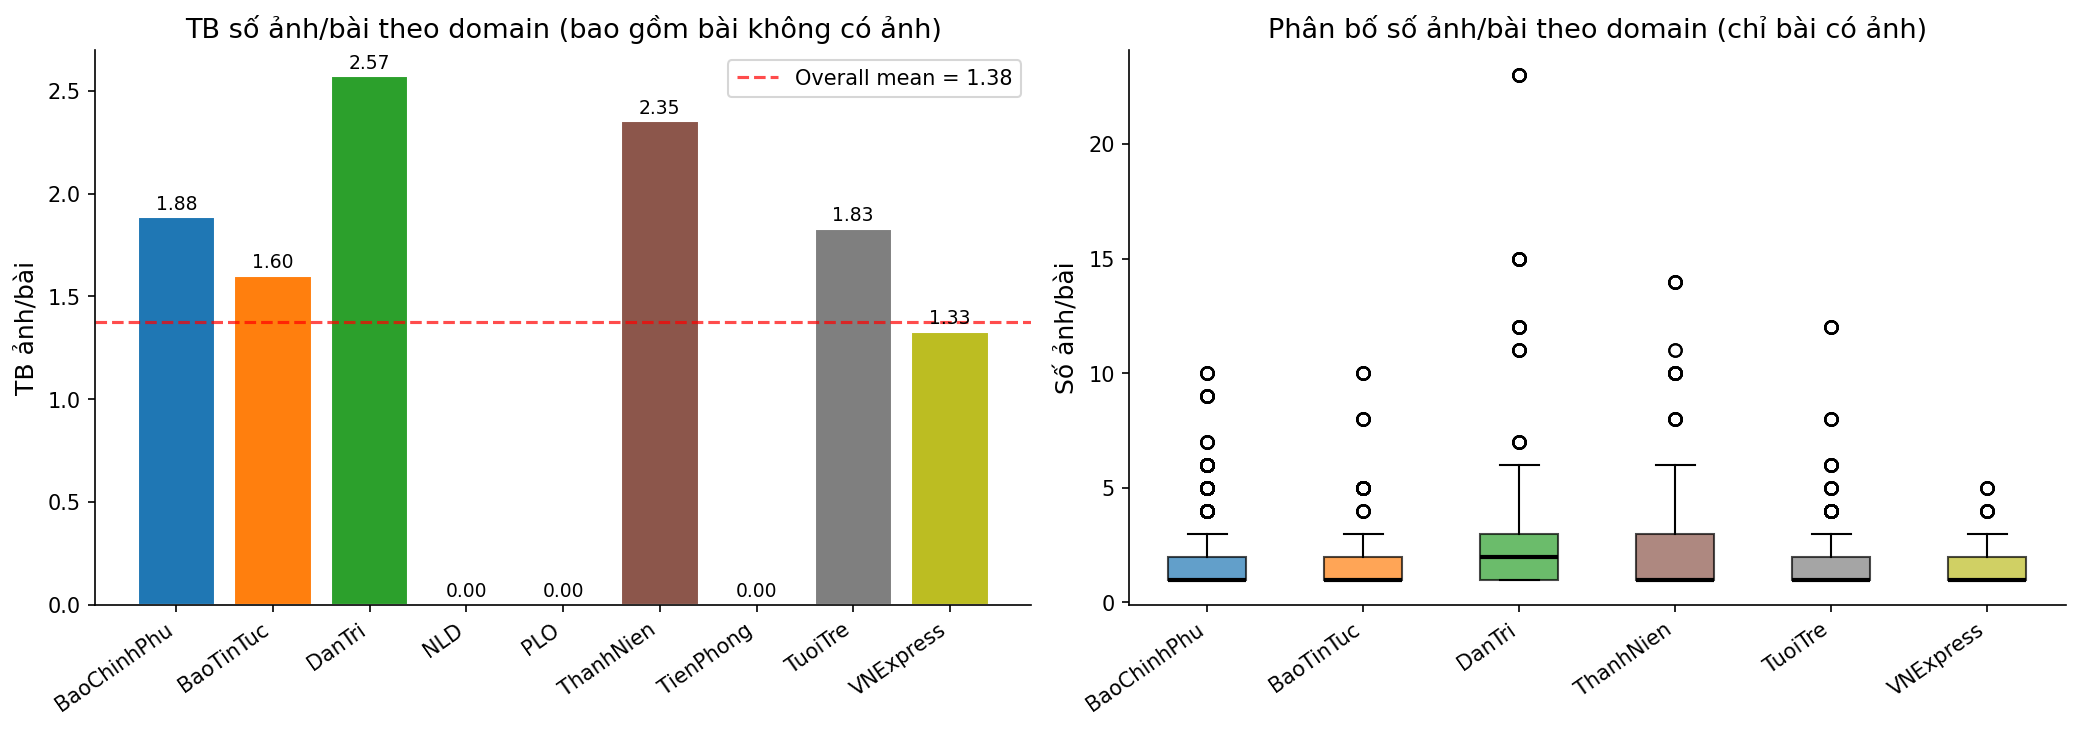

Saved: fig_d12_images_per_article_domain.png


In [ ]:
# Only articles with images
df_art_img = df_art[df_art.has_images].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- A: Mean images/article by domain (all) ---
mean_img_domain = df_art.groupby("domain")["image_count"].mean()
mean_img_domain = mean_img_domain.reindex(sorted(df_art.domain.unique()))
short_x = [DOMAIN_SHORT.get(d, d) for d in mean_img_domain.index]
colors_x = [DOMAIN_COLORS.get(d, "#999") for d in mean_img_domain.index]

bars = axes[0].bar(short_x, mean_img_domain.values, color=colors_x, edgecolor="white")
for bar, v in zip(bars, mean_img_domain.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[0].set_xticklabels(short_x, rotation=35, ha="right")
axes[0].set_ylabel("TB ảnh/bài")
axes[0].set_title("TB số ảnh/bài theo domain (bao gồm bài không có ảnh)")
axes[0].axhline(
    y=df_art.image_count.mean(),
    color="red",
    linestyle="--",
    label=f"Overall mean = {df_art.image_count.mean():.2f}",
    alpha=0.7,
)
axes[0].legend()

# --- B: Box plot images/article by domain (only with images) ---
domain_order_b = sorted(df_art_img.domain.unique())
data_box = [
    df_art_img[df_art_img.domain == d]["image_count"].values for d in domain_order_b
]
short_b = [DOMAIN_SHORT.get(d, d) for d in domain_order_b]
bp = axes[1].boxplot(
    data_box, patch_artist=True, medianprops=dict(color="black", linewidth=2)
)
for patch, d in zip(bp["boxes"], domain_order_b):
    patch.set_facecolor(DOMAIN_COLORS.get(d, "#999"))
    patch.set_alpha(0.7)
axes[1].set_xticklabels(short_b, rotation=35, ha="right")
axes[1].set_ylabel("Số ảnh/bài")
axes[1].set_title("Phân bố số ảnh/bài theo domain (chỉ bài có ảnh)")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig_d12_images_per_article_domain.png", bbox_inches="tight", dpi=150
)
plt.show()
print("Saved: fig_d12_images_per_article_domain.png")

## Kết luận — Danh sách hình đã lưu


In [ ]:
import glob

figs = sorted(glob.glob(str(OUTPUT_DIR / "fig_d*.png")))
print(f"✅ Đã lưu {len(figs)} hình:")
for f in figs:
    size_kb = Path(f).stat().st_size / 1024
    print(f"   {Path(f).name}  ({size_kb:.0f} KB)")

print()
print("📊 Tóm tắt chỉ số chính:")
print(f"   Tổng bài viết    : {len(df_art):,}")
print(
    f"   Bài có ảnh       : {df_art.has_images.sum():,} ({df_art.has_images.mean()*100:.1f}%)"
)
print(f"   Tổng ref ảnh     : {len(df_img):,}")
print(f"   File ảnh duy nhất: {df_img['path'].nunique():,}")
print(f"   Hệ số tái dùng   : {len(df_img)/df_img['path'].nunique():.1f}×")
print(
    f"   Ảnh có caption   : {df_img.has_caption.sum():,} ({df_img.has_caption.mean()*100:.1f}%)"
)
print(f"   TB caption chars : {df_img[df_img.has_caption].cap_chars.mean():.1f}")
print(f"   TB caption words : {df_img[df_img.has_caption].cap_words.mean():.1f}")
print(f"   TB file size     : {df_unique_imgs.file_size_kb.mean():.0f} KB")
print(f"   TB width         : {df_dims.width.mean():.0f} px")
print(f"   TB height        : {df_dims.height.mean():.0f} px")
print(f"   TB aspect ratio  : {df_dims.aspect_ratio.mean():.2f}")

✅ Đã lưu 12 hình:
   fig_d10_heatmap_domain_split.png  (93 KB)
   fig_d11_caption_cdf.png  (115 KB)
   fig_d12_images_per_article_domain.png  (81 KB)
   fig_d1_images_by_split.png  (79 KB)
   fig_d2_images_by_domain.png  (88 KB)
   fig_d3_images_per_article.png  (80 KB)
   fig_d4_caption_length.png  (146 KB)
   fig_d5_image_caption_coverage.png  (91 KB)
   fig_d6_image_reuse.png  (70 KB)
   fig_d7_file_size.png  (92 KB)
   fig_d8_image_dimensions.png  (139 KB)
   fig_d9_resolution_by_domain.png  (83 KB)

📊 Tóm tắt chỉ số chính:
   Tổng bài viết    : 7,232
   Bài có ảnh       : 4,769 (65.9%)
   Tổng ref ảnh     : 9,944
   File ảnh duy nhất: 1,391
   Hệ số tái dùng   : 7.1×
   Ảnh có caption   : 9,944 (100.0%)
   TB caption chars : 93.2
   TB caption words : 19.8
   TB file size     : 89 KB
   TB width         : 824 px
   TB height        : 556 px
   TB aspect ratio  : 1.50
